# NFL Contracts Predictions Capstone
## Research Question
  Can historical on-field performance data reliably predict the values for NFL Offensive position players' (QB, RB, WR, TE) next contract.

## Business Understanding
  The NFL salary cap is a year by year puzzle that can make or break the success of an NFL Franchise. Producing a model that is able to understand the fair market value for player contracts, given their recent and career production on the field will allow teams and players alike to better get a grasp of what makes sense and what is actually possible.

## Data Sources
  The data obtained for this analysis come from the nflverse online Github Repository. This is a collection of curated NFL data scraped from the web to compile all significant data needed for analysis of the NFL. Some sources include OvertheCap, NFL API's and feeds from major sports reporting agencies.

## Data Structure
  I will be loading Data involving individual player statistics, overall team statistics, Contract data and schedule data. I will review all the data and engineer different features to include in my end model.

## Expected Results
  I anticipate being able to create a model that will take in key player production metrics and success that will predict appropriate contract values within an error of 2 million per year average.

# Data Understanding

In this section I will be loading in the NFL data from the 2000 to 2025 NFL seasons for understanding and selection. Given the broad range of data available, I will be looking to curate and engineer the features that will provide the most context for contract predictions.

In [199]:
# Installing nflreadypy library for NFL Verse Data import
!pip install nflreadpy

In [200]:
import pandas as pd
import numpy as np
import nflreadpy as nfl
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)

In [201]:
# Season range for last 25 years of NFL Data
START_SEASON = 2000
END_SEASON = 2025

seasons = list(range(START_SEASON, END_SEASON + 1))

print(f"Loading data for seasons: {START_SEASON}–{END_SEASON}")

Loading data for seasons: 2000–2025


In [202]:
# Loaded Data and Cast to Pandas Dataframe given original Data import as Polars DataFrames
raw_player_stats = (nfl.load_player_stats(seasons=seasons)).to_pandas()
raw_team_stats = (nfl.load_team_stats(seasons=seasons)).to_pandas()
raw_contracts = (nfl.load_contracts()).to_pandas()
raw_schedules = (nfl.load_schedules(seasons=seasons)).to_pandas()
print("Done!")

Done!


In [203]:
# Quick glance at the Player Stats Dataframes & Structure
display(raw_player_stats.head())
raw_player_stats.info()

,player_id,player_name,player_display_name,position,position_group,headshot_url,season,week,season_type,team,opponent_team,completions,attempts,passing_yards,passing_tds,passing_interceptions,sacks_suffered,sack_yards_lost,sack_fumbles,sack_fumbles_lost,passing_air_yards,passing_yards_after_catch,passing_first_downs,passing_epa,passing_cpoe,passing_2pt_conversions,pacr,carries,rushing_yards,rushing_tds,rushing_fumbles,rushing_fumbles_lost,rushing_first_downs,rushing_epa,rushing_2pt_conversions,receptions,targets,receiving_yards,receiving_tds,receiving_fumbles,receiving_fumbles_lost,receiving_air_yards,receiving_yards_after_catch,receiving_first_downs,receiving_epa,receiving_2pt_conversions,racr,target_share,air_yards_share,wopr,special_teams_tds,def_tackles_solo,def_tackles_with_assist,def_tackle_assists,def_tackles_for_loss,def_tackles_for_loss_yards,def_fumbles_forced,def_sacks,def_sack_yards,def_qb_hits,def_interceptions,def_interception_yards,def_pass_defended,def_tds,def_fumbles,def_safeties,misc_yards,fumble_recovery_own,fumble_recovery_yards_own,fumble_recovery_opp,fumble_recovery_yards_opp,fumble_recovery_tds,penalties,penalty_yards,punt_returns,punt_return_yards,kickoff_returns,kickoff_return_yards,fg_made,fg_att,fg_missed,fg_blocked,fg_long,fg_pct,fg_made_0_19,fg_made_20_29,fg_made_30_39,fg_made_40_49,fg_made_50_59,fg_made_60_,fg_missed_0_19,fg_missed_20_29,fg_missed_30_39,fg_missed_40_49,fg_missed_50_59,fg_missed_60_,fg_made_list,fg_missed_list,fg_blocked_list,fg_made_distance,fg_missed_distance,fg_blocked_distance,pat_made,pat_att,pat_missed,pat_blocked,pat_pct,gwfg_made,gwfg_att,gwfg_missed,gwfg_blocked,gwfg_distance,fantasy_points,fantasy_points_ppr,game_id
0,0,None,None,None,None,None,2000,1,REG,SF,ATL,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000000,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,18,104,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,None,None,None,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0.0,0.0,None
1,00-0000003,A.al-Jabbar,Abdul-Karim al-Jabbar,RB,RB,https://static.www.nfl.com/image/private/f_aut...,2000,1,REG,IND,KC,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,1,-2,0,0,0,0,-0.549944,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000000,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,10,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,None,None,None,0,0,0,0,0,0,0,NaN,0,0,0,0,0,-0.2,-0.2,None
2,00-0000007,R.Abdullah,Rabih Abdullah,RB,RB,https://static.www.nfl.com/image/private/f_aut...,2000,1,REG,TB,NE,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,0,0,0,0,0,0,NaN,0,1,1,3,0,0,0,0,0,0,-0.31212,0,0.0,0.041667,NaN,NaN,0,1,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,None,None,None,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0.3,1.3,None
3,00-0000008,R.Abdullah,Rahim Abdullah,OLB,LB,https://static.www.nfl.com/image/private/f_aut...,2000,1,REG,CLE,JAX,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000000,NaN,NaN,0,1,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,None,None,None,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0.0,0.0,None
4,00-0000017,D.Abraham,Donnie Abraham,CB,DB,https://static.www.nfl.com/image/private/f_aut...,2000,1,REG,TB,NE,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000000,NaN,NaN,0,2,1,1,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,None,None,None,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0.0,0.0,None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459317 entries, 0 to 459316
Columns: 115 entries, player_id to game_id
dtypes: float64(16), int32(86), object(13)
memory usage: 252.3+ MB


In [204]:
# Quick glance at the Contract Dataframes & Structure
display(raw_contracts.head())
raw_contracts.info()

,player,position,team,is_active,year_signed,years,value,apy,guaranteed,apy_cap_pct,inflated_value,inflated_apy,inflated_guaranteed,player_page,otc_id,gsis_id,date_of_birth,height,weight,college,draft_year,draft_round,draft_overall,draft_team,cols
0,Joe Burrow,QB,Bengals,True,2023,5.0,275.000,55.000000,146.510,0.245,368.460854,73.692171,196.302544,https://overthecap.com/player/joe-burrow/8741/,8741,00-0036442,None,"6'4""",215,LSU,2020.0,1.0,1.0,Bengals,"[{'year': '2020', 'team': 'Bengals', 'base_sal..."
1,Aaron Rodgers,QB,NYJ/GB,False,2022,3.0,150.815,50.271667,101.415,0.241,218.181931,72.727311,146.715648,https://overthecap.com/player/aaron-rodgers/1085/,1085,00-0023459,None,"6'2""",225,California,2005.0,1.0,24.0,Packers,"[{'year': '2005', 'team': 'Packers', 'base_sal..."
2,Josh Allen,QB,Bills,False,2021,6.0,258.000,43.000000,100.000,0.236,425.806027,70.967671,165.041096,https://overthecap.com/player/josh-allen/6892/,6892,00-0034857,None,"6'5""",233,Wyoming,2018.0,1.0,7.0,Bills,"[{'year': '2018', 'team': 'Bills', 'base_salar..."
3,Russell Wilson,QB,Broncos,False,2022,5.0,245.000,49.000000,124.000,0.235,354.438040,70.887608,179.389049,https://overthecap.com/player/russell-wilson/1...,1569,00-0029263,"November 29, 1988","5'11""",206,Wisconsin,2012.0,3.0,75.0,Seahawks,"[{'year': '2012', 'team': 'Seahawks', 'base_sa..."
4,Dak Prescott,QB,Cowboys,True,2024,4.0,240.000,60.000000,129.000,0.235,283.038371,70.759593,152.133125,https://overthecap.com/player/dak-prescott/4848/,4848,00-0033077,None,"6'2""",226,Mississippi State,2016.0,4.0,135.0,Cowboys,"[{'year': '2016', 'team': 'Cowboys', 'base_sal..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51593 entries, 0 to 51592
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player               51593 non-null  object 
 1   position             51593 non-null  object 
 2   team                 51593 non-null  object 
 3   is_active            51593 non-null  bool   
 4   year_signed          51593 non-null  int32  
 5   years                51568 non-null  float64
 6   value                51593 non-null  float64
 7   apy                  51593 non-null  float64
 8   guaranteed           51593 non-null  float64
 9   apy_cap_pct          51593 non-null  float64
 10  inflated_value       51593 non-null  float64
 11  inflated_apy         51593 non-null  float64
 12  inflated_guaranteed  51593 non-null  float64
 13  player_page          51593 non-null  object 
 14  otc_id               51593 non-null  int32  
 15  gsis_id              47425 non-null 

In [205]:
# Quick glance at the Team Stats Dataframes & Structure
display(raw_team_stats.head())
raw_team_stats.info()

,season,week,team,season_type,opponent_team,completions,attempts,passing_yards,passing_tds,passing_interceptions,sacks_suffered,sack_yards_lost,sack_fumbles,sack_fumbles_lost,passing_air_yards,passing_yards_after_catch,passing_first_downs,passing_epa,passing_cpoe,passing_2pt_conversions,carries,rushing_yards,rushing_tds,rushing_fumbles,rushing_fumbles_lost,rushing_first_downs,rushing_epa,rushing_2pt_conversions,receptions,targets,receiving_yards,receiving_tds,receiving_fumbles,receiving_fumbles_lost,receiving_air_yards,receiving_yards_after_catch,receiving_first_downs,receiving_epa,receiving_2pt_conversions,special_teams_tds,def_tackles_solo,def_tackles_with_assist,def_tackle_assists,def_tackles_for_loss,def_tackles_for_loss_yards,def_fumbles_forced,def_sacks,def_sack_yards,def_qb_hits,def_interceptions,def_interception_yards,def_pass_defended,def_tds,def_fumbles,def_safeties,misc_yards,fumble_recovery_own,fumble_recovery_yards_own,fumble_recovery_opp,fumble_recovery_yards_opp,fumble_recovery_tds,penalties,penalty_yards,timeouts,punt_returns,punt_return_yards,kickoff_returns,kickoff_return_yards,fg_made,fg_att,fg_missed,fg_blocked,fg_long,fg_pct,fg_made_0_19,fg_made_20_29,fg_made_30_39,fg_made_40_49,fg_made_50_59,fg_made_60_,fg_missed_0_19,fg_missed_20_29,fg_missed_30_39,fg_missed_40_49,fg_missed_50_59,fg_missed_60_,fg_made_list,fg_missed_list,fg_blocked_list,fg_made_distance,fg_missed_distance,fg_blocked_distance,pat_made,pat_att,pat_missed,pat_blocked,pat_pct,gwfg_made,gwfg_att,gwfg_missed,gwfg_blocked,gwfg_distance,game_id
0,2000,1,ARI,REG,NYG,28,49,318,2,3,1,-6,0,0,12,318,15,1.011349,NaN,0,20,43,0,1,1,4,-6.913380,0,28,47,318,2,0,0,12,0,15,2.382013,0,0,38,21,21,5,14,1,0.0,0.0,0,1,11,1,0,0,0,0,1,1,1,1,0,1,5,6,2,17,4,133,1,1,0,0,32.0,1.00,0,0,1,0,0,0,0,0,0,0,0,0,32,None,None,32,0,0,1,1,0,0,1.0,0,0,0,0,0,None
1,2000,1,ATL,REG,SF,16,31,264,2,0,0,0,0,0,0,264,13,10.218793,NaN,0,32,95,0,2,1,6,-11.639264,0,16,30,264,2,0,0,0,0,13,10.346253,0,0,41,10,10,1,6,3,1.0,6.0,1,1,36,4,1,0,0,0,0,0,0,0,0,4,51,3,2,21,5,145,5,5,0,0,48.0,1.00,0,1,0,4,0,0,0,0,0,0,0,0,43;44;24;44;48,None,None,203,0,0,3,3,0,0,1.0,0,0,0,0,0,None
2,2000,1,BAL,REG,PIT,18,32,199,1,0,1,-3,0,0,0,199,9,2.892977,NaN,0,36,140,0,0,0,9,-0.812932,0,18,30,199,1,0,0,0,0,9,5.271726,0,0,28,8,14,2,12,2,1.0,6.0,0,0,0,6,0,0,0,0,0,0,1,1,0,6,42,4,5,50,1,38,3,3,0,0,33.0,1.00,0,2,1,0,0,0,0,0,0,0,0,0,23;26;33,None,None,82,0,0,1,1,0,0,1.0,0,0,0,0,0,None
3,2000,1,BUF,REG,TEN,13,26,174,1,0,5,-37,0,0,0,174,9,-4.197206,NaN,0,35,129,0,0,0,6,-10.088240,0,13,24,174,1,0,0,0,0,9,2.890964,0,0,36,7,21,3,24,1,4.0,33.0,3,1,8,6,0,0,0,0,0,0,0,0,0,6,91,3,5,10,3,35,3,4,1,0,42.0,0.75,0,0,1,2,0,0,0,0,0,0,1,0,42;41;33,51,None,116,51,0,1,1,0,0,1.0,1,1,0,0,33,None
4,2000,1,CAR,REG,WAS,17,26,183,1,0,6,-59,1,1,0,183,6,-3.202182,NaN,0,20,112,0,0,0,4,-0.356698,0,17,25,183,1,0,0,0,0,6,6.882382,0,1,49,7,7,3,3,0,0.0,0.0,0,0,0,4,0,0,0,0,0,0,0,0,0,9,65,2,0,0,5,189,1,2,1,0,29.0,0.50,0,1,0,0,0,0,0,1,0,0,0,0,29,27,None,29,27,0,2,2,0,0,1.0,0,0,0,0,0,None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14014 entries, 0 to 14013
Columns: 103 entries, season to game_id
dtypes: float64(9), int32(87), object(7)
memory usage: 6.4+ MB


In [206]:
# Quick glance at the Schedules Dataframes & Structure
display(raw_schedules.head())
raw_schedules.info()

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,old_game_id,gsis,nfl_detail_id,pfr,pff,espn,ftn,away_rest,home_rest,away_moneyline,home_moneyline,spread_line,away_spread_odds,home_spread_odds,total_line,under_odds,over_odds,div_game,roof,surface,temp,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
0,2000_01_SF_ATL,2000,REG,1,2000-09-03,Sunday,13:00,SF,28,ATL,36,Home,8,64,0,2000090310,998,None,200009030atl,NaN,200903001,NaN,7,7,NaN,NaN,6.5,NaN,NaN,46.5,NaN,NaN,1,dome,astroturf,NaN,NaN,00-0005755,00-0002876,Jeff Garcia,Chris Chandler,Steve Mariucci,Dan Reeves,Walt Coleman,ATL00,Georgia Dome
1,2000_01_JAX_CLE,2000,REG,1,2000-09-03,Sunday,13:00,JAX,27,CLE,7,Home,-20,34,0,2000090306,994,None,200009030cle,NaN,200903005,NaN,7,7,NaN,NaN,-10.5,NaN,NaN,38.5,NaN,NaN,1,outdoors,grass,78.0,6.0,00-0002110,00-0003535,Mark Brunell,Tim Couch,Tom Coughlin,Chris Palmer,Bernie Kukar,CLE00,Cleveland Browns Stadium
2,2000_01_IND_KC,2000,REG,1,2000-09-03,Sunday,13:00,IND,27,KC,14,Home,-13,41,0,2000090305,993,None,200009030kan,NaN,200903012,NaN,7,7,NaN,NaN,-3.5,NaN,NaN,44.0,NaN,NaN,0,outdoors,grass,90.0,5.0,00-0010346,00-0006300,Peyton Manning,Elvis Grbac,Jim Mora,Gunther Cunningham,Larry Nemmers,KAN00,Arrowhead Stadium
3,2000_01_CHI_MIN,2000,REG,1,2000-09-03,Sunday,13:00,CHI,27,MIN,30,Home,3,57,0,2000090303,991,None,200009030min,NaN,200903016,NaN,7,7,NaN,NaN,4.5,NaN,NaN,46.5,NaN,NaN,1,dome,astroturf,NaN,NaN,00-0011044,00-0003739,Cade McNown,Daunte Culpepper,Dick Jauron,Dennis Green,Ed Hochuli,MIN00,Hubert H. Humphrey Metrodome
4,2000_01_TB_NE,2000,REG,1,2000-09-03,Sunday,13:00,TB,21,NE,16,Home,-5,37,0,2000090312,1000,None,200009030nwe,NaN,200903017,NaN,7,7,NaN,NaN,-3.0,NaN,NaN,36.0,NaN,NaN,0,outdoors,grass,71.0,5.0,00-0009266,00-0001361,Shaun King,Drew Bledsoe,Tony Dungy,Bill Belichick,Jeff Triplette,BOS99,Foxboro Stadium


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7017 entries, 0 to 7016
Data columns (total 46 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   game_id           7017 non-null   object 
 1   season            7017 non-null   int32  
 2   game_type         7017 non-null   object 
 3   week              7017 non-null   int32  
 4   gameday           7017 non-null   object 
 5   weekday           7017 non-null   object 
 6   gametime          7017 non-null   object 
 7   away_team         7017 non-null   object 
 8   away_score        7017 non-null   int32  
 9   home_team         7017 non-null   object 
 10  home_score        7017 non-null   int32  
 11  location          7017 non-null   object 
 12  result            7017 non-null   int32  
 13  total             7017 non-null   int32  
 14  overtime          7017 non-null   int32  
 15  old_game_id       7017 non-null   object 
 16  gsis              7017 non-null   int32  


Initial review of our data shows the stats for each player being on a week by week interval, which is too specific for our end goal. We will need to address this for an attempt at a decent model. The same applied for the team statst dataset.   


For the Contracts data, there is more information that is needed for us. Additionally we would want to create some new features based on the data given that would be more useful in a model.   

The schedule data frame provides us with specific team and QB wins and losses for games in a seaon. This will be helpful when considering playoff wins, losses and superbowls.

In [207]:
# Want to filter player specific dataframes to only positions of interest.
OFF_POSITIONS = ["QB", "RB", "WR", "TE"]
final_dfs = []

filt_player_stats = raw_player_stats[raw_player_stats['position'].isin(OFF_POSITIONS)].copy()
filt_contracts = raw_contracts[raw_contracts['position'].isin(OFF_POSITIONS)].copy()

In [208]:
# @title ###Initial Raw Data Exploration
#====================================
# Contract Data
#====================================
print(f'Contract columns are as follows :')
mid = len(filt_contracts.columns) // 2
for i, col in enumerate(filt_contracts.columns):
  if i == mid:
    print()
  print(col, end = ' / ')


Contract columns are as follows :
player / position / team / is_active / year_signed / years / value / apy / guaranteed / apy_cap_pct / inflated_value / inflated_apy / 
inflated_guaranteed / player_page / otc_id / gsis_id / date_of_birth / height / weight / college / draft_year / draft_round / draft_overall / draft_team / cols / 

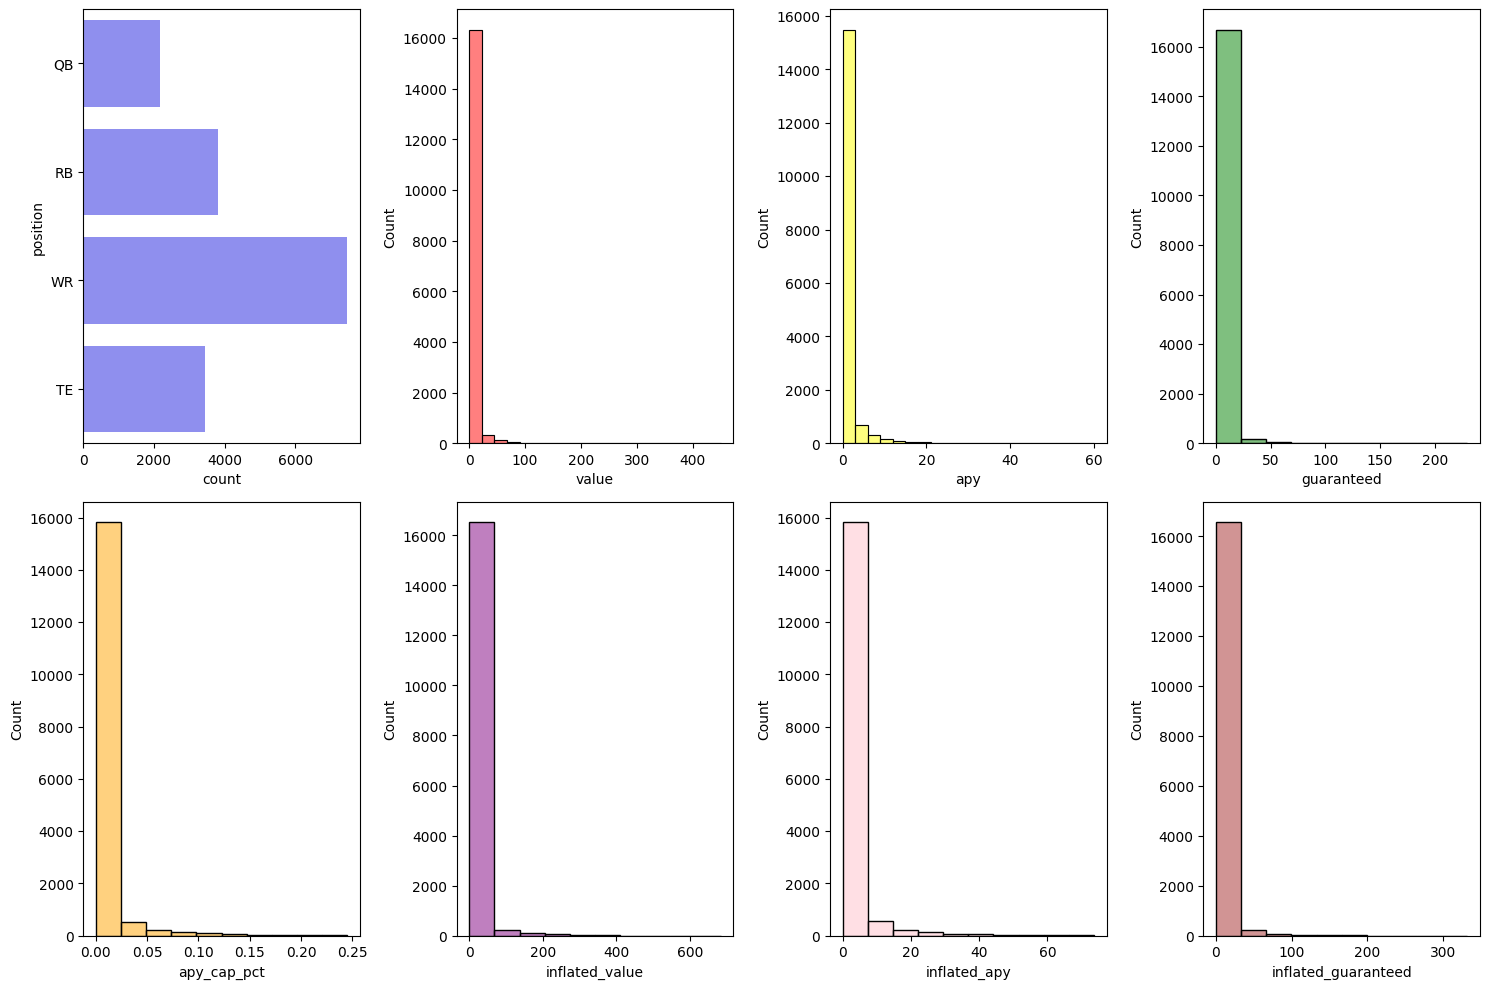

In [209]:
# Contracct Counts for Key Metrics
fig, ax = plt.subplots(ncols=4 , nrows=2, figsize=(15,10))
sns.countplot(filt_contracts['position'], alpha= 0.5, color = 'blue', ax = ax[0,0])
sns.histplot(filt_contracts['value'], bins = 20,  alpha= 0.5, color = 'red', ax=ax[0,1])
sns.histplot(filt_contracts['apy'], bins = 20, alpha= 0.5, color = 'yellow', ax=ax[0,2])
sns.histplot(filt_contracts['guaranteed'], bins = 10,  alpha= 0.5, color = 'green', ax=ax[0,3])
sns.histplot(filt_contracts['apy_cap_pct'], bins = 10,  alpha= 0.5, color = 'orange', ax=ax[1,0])
sns.histplot(filt_contracts['inflated_value'], bins = 10,  alpha= 0.5, color = 'purple', ax=ax[1,1])
sns.histplot(filt_contracts['inflated_apy'], bins = 10,  alpha= 0.5, color = 'pink', ax=ax[1,2])
sns.histplot(filt_contracts['inflated_guaranteed'], bins = 10,  alpha= 0.5, color = 'brown', ax=ax[1,3])
plt.tight_layout()
plt.show()

<Axes: xlabel='inflated_guaranteed', ylabel='Count'>

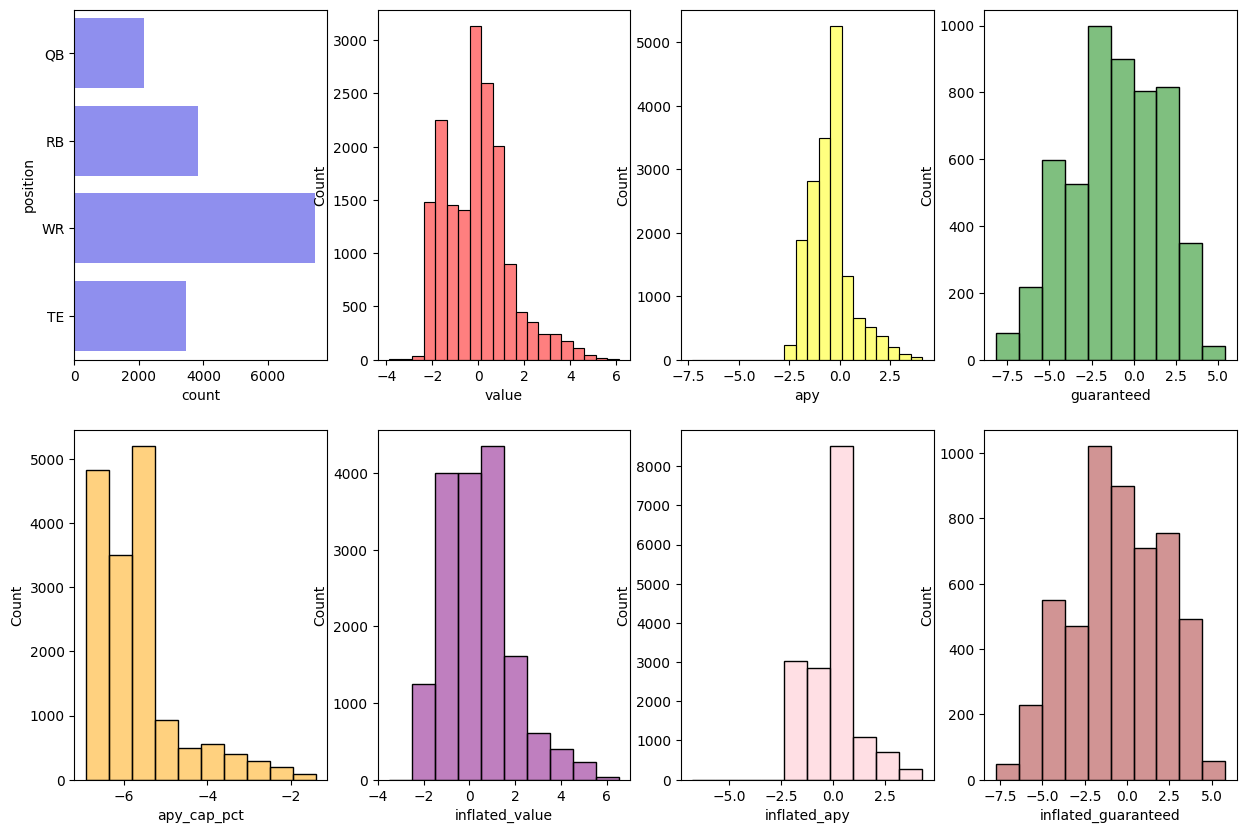

In [210]:
# Log Tranformed Values
fig, ax = plt.subplots(ncols=4, nrows=2, figsize=(15,10))
sns.countplot(filt_contracts['position'], alpha= 0.5, color = 'blue', ax = ax[0,0])
sns.histplot(np.log(filt_contracts['value']), bins = 20,  alpha= 0.5, color = 'red', ax=ax[0,1])
sns.histplot(np.log(filt_contracts['apy']), bins = 20, alpha= 0.5, color = 'yellow', ax=ax[0,2])
sns.histplot(np.log(filt_contracts['guaranteed']), bins = 10,  alpha= 0.5, color = 'green', ax=ax[0,3])
sns.histplot(np.log(filt_contracts['apy_cap_pct']), bins = 10,  alpha= 0.5, color = 'orange', ax=ax[1,0])
sns.histplot(np.log(filt_contracts['inflated_value']), bins = 10,  alpha= 0.5, color = 'purple', ax=ax[1,1])
sns.histplot(np.log(filt_contracts['inflated_apy']), bins = 10,  alpha= 0.5, color = 'pink', ax=ax[1,2])
sns.histplot(np.log(filt_contracts['inflated_guaranteed']), bins = 10,  alpha= 0.5, color = 'brown', ax=ax[1,3])

In [211]:
filt_contracts['log_value'] = np.log(filt_contracts['value'])
filt_contracts['log_apy'] = np.log(filt_contracts['apy'])
filt_contracts['log_gtd'] = np.log(filt_contracts['guaranteed'])
filt_contracts['log_apycappct'] = np.log(filt_contracts['apy_cap_pct'])
filt_contracts['log_inf_value'] = np.log(filt_contracts['inflated_value'])
filt_contracts['log_inf_apy'] = np.log(filt_contracts['inflated_apy'])
filt_contracts['log_inf_gtd'] = np.log(filt_contracts['inflated_guaranteed'])

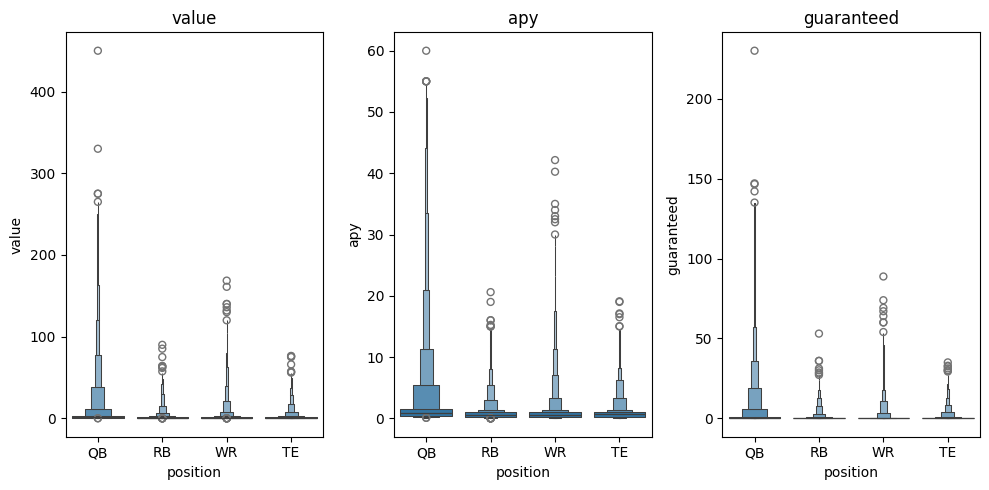

In [212]:
# Contract Features strip plot
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 5))
cols = ['value','apy','guaranteed']
ax = ax.flatten()
for i, col in enumerate(cols):
    sns.boxenplot(x='position', y=col, data=filt_contracts, ax=ax[i])
    ax[i].set_title(col)
plt.tight_layout()
plt.show()

In [213]:
quart = len(filt_player_stats.columns) // 8
for i , col in enumerate(filt_player_stats.columns):
  if i % quart == 0:
    print()
  print(col, end = ' / ')


player_id / player_name / player_display_name / position / position_group / headshot_url / season / week / season_type / team / opponent_team / completions / attempts / passing_yards / 
passing_tds / passing_interceptions / sacks_suffered / sack_yards_lost / sack_fumbles / sack_fumbles_lost / passing_air_yards / passing_yards_after_catch / passing_first_downs / passing_epa / passing_cpoe / passing_2pt_conversions / pacr / carries / 
rushing_yards / rushing_tds / rushing_fumbles / rushing_fumbles_lost / rushing_first_downs / rushing_epa / rushing_2pt_conversions / receptions / targets / receiving_yards / receiving_tds / receiving_fumbles / receiving_fumbles_lost / receiving_air_yards / 
receiving_yards_after_catch / receiving_first_downs / receiving_epa / receiving_2pt_conversions / racr / target_share / air_yards_share / wopr / special_teams_tds / def_tackles_solo / def_tackles_with_assist / def_tackle_assists / def_tackles_for_loss / def_tackles_for_loss_yards / 
def_fumbles_forced /

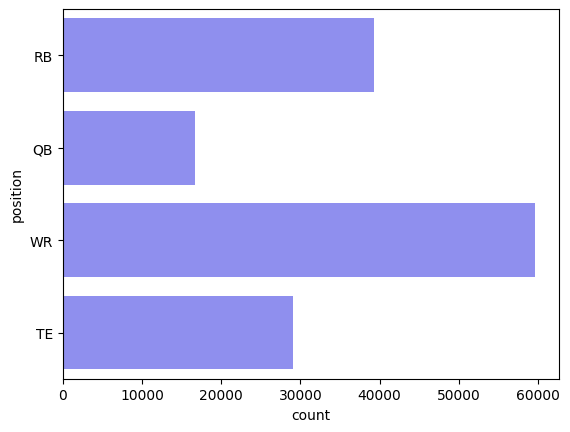

In [214]:
#====================================
# Player Stats Data - Weekly
#====================================
# Counts for position
sns.countplot(filt_player_stats['position'], alpha= 0.5, color = 'blue')
plt.show()

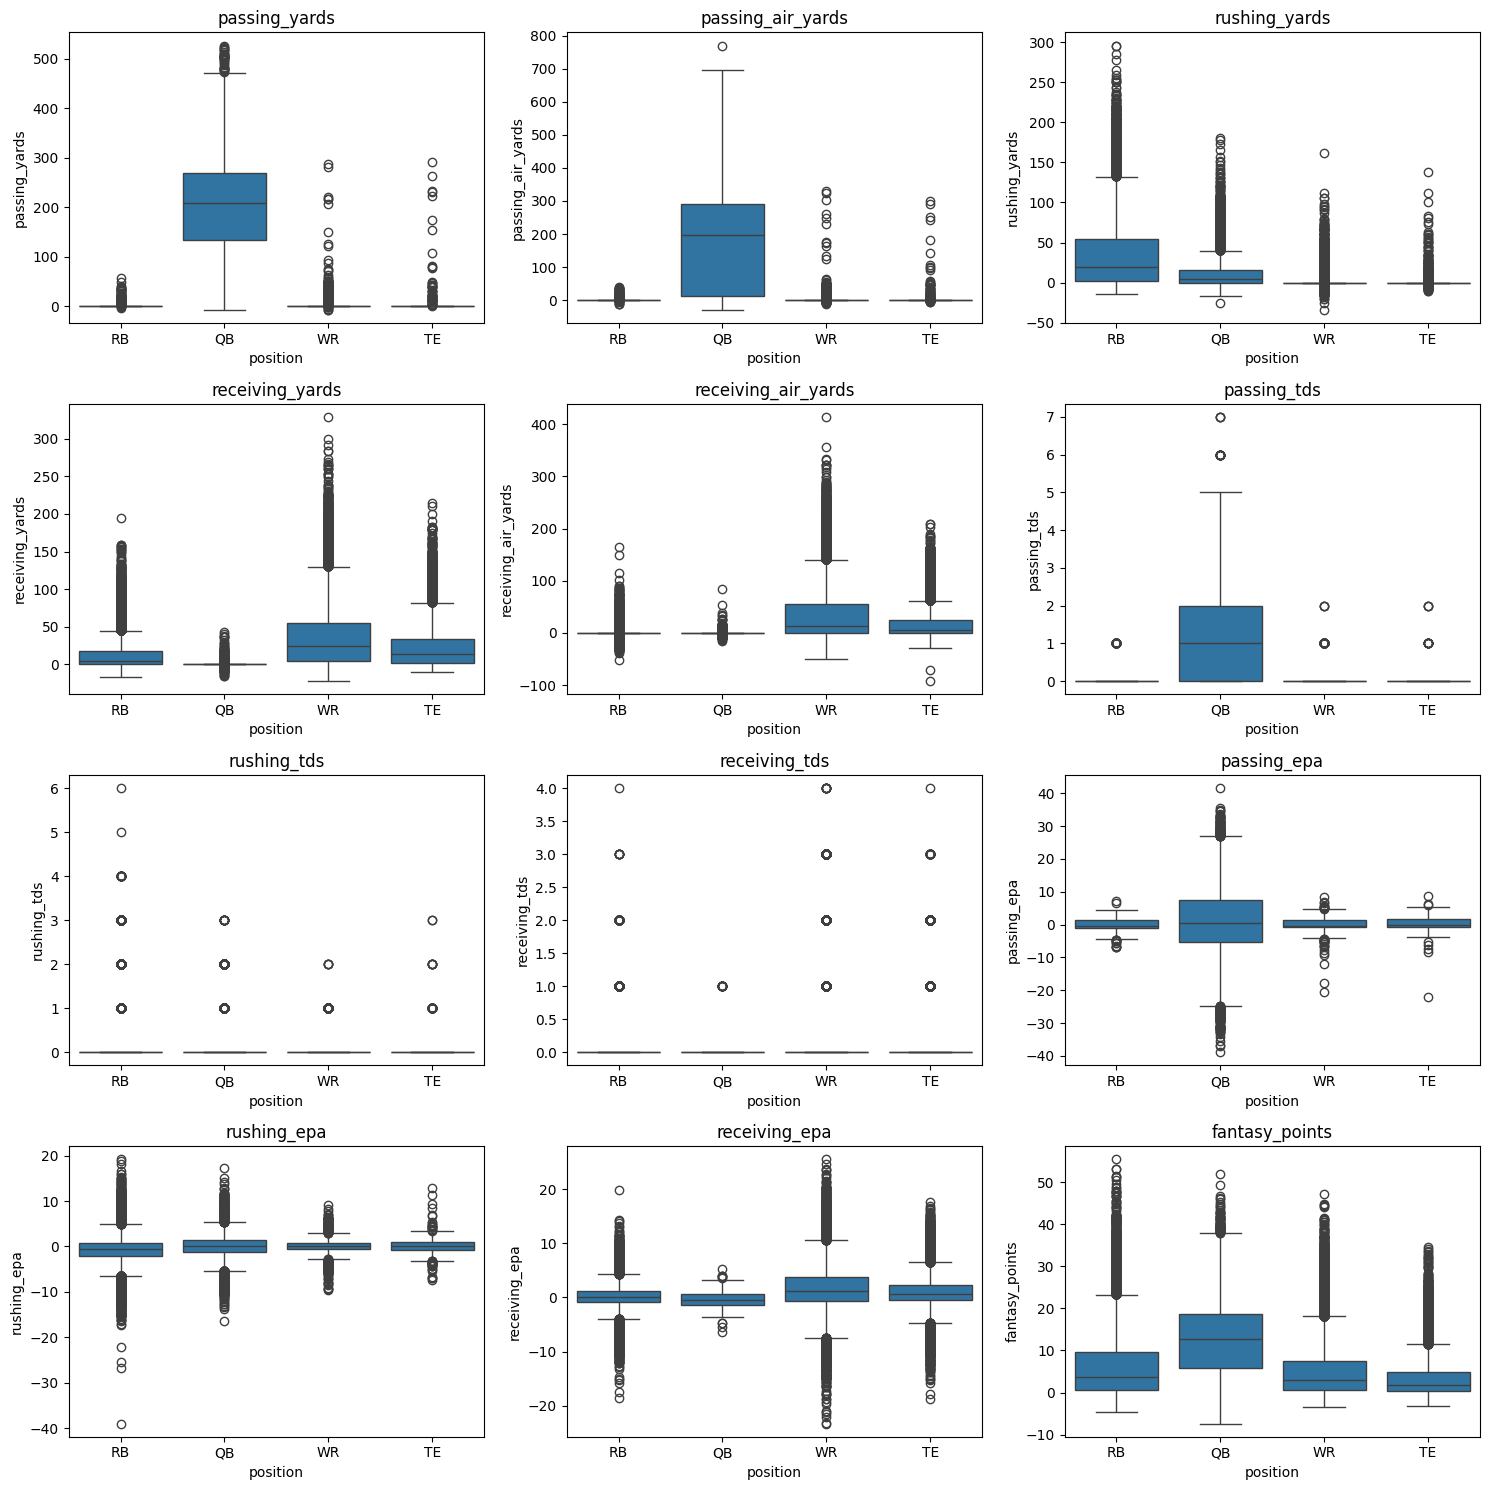

In [215]:
# Stats data plots for position
stats = ('_yards','_tds','_epa')
s_type = ('passing','rushing','receiving')
ovr_stats = []
for stat in stats:
  matched = [col for col in filt_player_stats.columns
             if col.endswith(stat)
             and col.startswith(s_type)
             ]
  ovr_stats.extend(matched)
fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(15, 15))
ax = ax.flatten()
for i, col in enumerate(ovr_stats):
    sns.boxplot(x='position', y=col, data=filt_player_stats, ax=ax[i])
    ax[i].set_title(col)
sns.boxplot(x='position', y='fantasy_points', data=filt_player_stats, ax=ax[11])
ax[11].set_title('fantasy_points')
plt.tight_layout()
plt.show()

In [216]:
player_stats_to_keep = ['player_id',
                    'player_display_name',
                    'team',
                    'position',
                    'season',
                    'week',
                    'season_type',
                    'completions',
                    'attempts',
                    'passing_yards',
                    'passing_tds',
                    'passing_interceptions',
                    'sacks_suffered',
                    'passing_air_yards',
                    'passing_yards_after_catch',
                    'passing_first_downs',
                    'passing_epa',
                    'carries',
                    'rushing_yards',
                    'rushing_tds',
                    'rushing_fumbles',
                    'rushing_first_downs',
                    'rushing_epa',
                    'receptions',
                    'targets',
                    'receiving_yards',
                    'receiving_tds',
                    'receiving_fumbles',
                    'receiving_air_yards',
                    'receiving_yards_after_catch',
                    'receiving_first_downs',
                    'receiving_epa']
player_stats = filt_player_stats[player_stats_to_keep].copy()

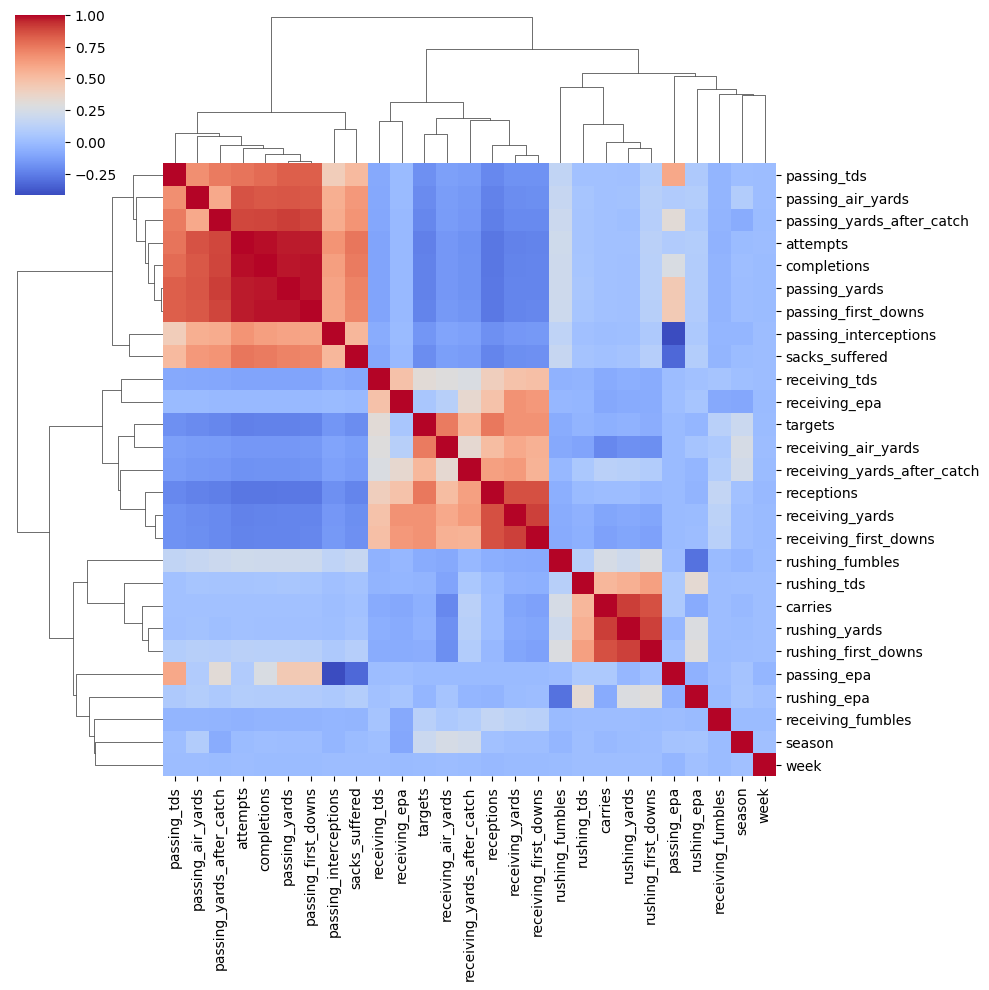

In [217]:
# Creation of a heatmap for understanding features.
player_corr = player_stats.corr(numeric_only = True)
sns.clustermap(player_corr, cmap= 'coolwarm')
plt.show()

In [218]:
# Look at the Columns in the contracts dataframe.
raw_contracts.columns

Index(['player', 'position', 'team', 'is_active', 'year_signed', 'years',
       'value', 'apy', 'guaranteed', 'apy_cap_pct', 'inflated_value',
       'inflated_apy', 'inflated_guaranteed', 'player_page', 'otc_id',
       'gsis_id', 'date_of_birth', 'height', 'weight', 'college', 'draft_year',
       'draft_round', 'draft_overall', 'draft_team', 'cols'],
      dtype='object')

In [219]:
# @title ####Contract Data Cleaning Code Block

# Identify which columns are significant to keep.
contracts_cols_to_keep = ['player',
                          'position',
                          'team',
                          'year_signed',
                          'years',
                          'value',
                          'apy',
                          'guaranteed',
                          'apy_cap_pct',
                          'draft_year',
                          'draft_team',
                          'log_value',
                          'log_apy',
                          'log_gtd',
                          'log_apycappct'
                          ]

# Filter out columns of interest
contracts_filtered = filt_contracts[contracts_cols_to_keep].copy()

# Replace year_signed values that are 0 with draft year, given rookie contract start.
contracts_filtered['year_signed'] = np.where(contracts_filtered['year_signed'] == 0, contracts_filtered['draft_year'], contracts_filtered['year_signed'])

# Drop any entries where no information about year_signed or draft year.
contracts_filtered = contracts_filtered.dropna(subset=['year_signed','draft_year'])

# Drop any entries where draft year is ahead of year signed
contracts_filtered = contracts_filtered[contracts_filtered['year_signed'] >= contracts_filtered['draft_year']]

# Filter data to remove multiple contracts within the same year, data includes
# players released and re-signed in same season. Keeping only most recent
# contract.
contracts_filtered = contracts_filtered.sort_index().drop_duplicates(['player','year_signed'], keep = 'last')

# Filling years null values with 1, assuming minimum 1 year deal.
contracts_filtered['years'] = contracts_filtered['years'].fillna(1)

# Added a new column for contract type between
# rookie and veteran
contracts_filtered['contract_type'] = np.where(contracts_filtered['year_signed'] == contracts_filtered['draft_year'],'rookie','veteran')
contracts_filtered['exp'] = contracts_filtered['year_signed'] -  contracts_filtered['draft_year']

# Sorting contracts data based on player and year signed
tracked_contracts = contracts_filtered.sort_values(['player','year_signed'])

# Created new column tracking previous team for contract type purposes
# Rookie contracts are not given due to performance, but by draft position.
tracked_contracts['prev_team'] = np.where(tracked_contracts['contract_type'] == 'veteran', tracked_contracts.groupby('player')['team'].shift(1), tracked_contracts['team'])

# Establishing conditions and choices for new contract_event column which will be the basis of our final data set.
contract_conditions = [
    (tracked_contracts['contract_type'] == 'rookie'),
    (tracked_contracts['contract_type'] == 'veteran') & (tracked_contracts['team'] == tracked_contracts['prev_team']),
    (tracked_contracts['contract_type'] == 'veteran') & (tracked_contracts['team'] != tracked_contracts['prev_team'])
]
contract_choices = ['rookie_deal', 'extension', 'new_team_signing' ]
tracked_contracts['contract_event'] = np.select(contract_conditions,contract_choices, default = 'unknown')

# Dropping players that do not have a previous team. No previous teams implies
# Free Agents with no stats leading to contract.
tracked_contracts = tracked_contracts.dropna(subset=['prev_team'])

# Filter Dataframe for contracts to keep only players that joined league after 2000
# to avoid missing data from previous seasons.
contract_final = tracked_contracts[tracked_contracts['draft_year'] > 2000].copy().reset_index(drop=True)

# Creating Contract ID column to differentiate different contracts for same player
contract_final['contract_id'] = contract_final.index + 1

# Clean up the dataframe converting floats to ints where needed.
contract_final = contract_final.convert_dtypes()


In [220]:
# Understand Columns in the player_stats data frame
filt_player_stats.columns.tolist()

['player_id',
 'player_name',
 'player_display_name',
 'position',
 'position_group',
 'headshot_url',
 'season',
 'week',
 'season_type',
 'team',
 'opponent_team',
 'completions',
 'attempts',
 'passing_yards',
 'passing_tds',
 'passing_interceptions',
 'sacks_suffered',
 'sack_yards_lost',
 'sack_fumbles',
 'sack_fumbles_lost',
 'passing_air_yards',
 'passing_yards_after_catch',
 'passing_first_downs',
 'passing_epa',
 'passing_cpoe',
 'passing_2pt_conversions',
 'pacr',
 'carries',
 'rushing_yards',
 'rushing_tds',
 'rushing_fumbles',
 'rushing_fumbles_lost',
 'rushing_first_downs',
 'rushing_epa',
 'rushing_2pt_conversions',
 'receptions',
 'targets',
 'receiving_yards',
 'receiving_tds',
 'receiving_fumbles',
 'receiving_fumbles_lost',
 'receiving_air_yards',
 'receiving_yards_after_catch',
 'receiving_first_downs',
 'receiving_epa',
 'receiving_2pt_conversions',
 'racr',
 'target_share',
 'air_yards_share',
 'wopr',
 'special_teams_tds',
 'def_tackles_solo',
 'def_tackles_with_a

In [221]:
# @title ####Stat Name abbreviation Dictionary Code Block
new_stat_names = {'completions': 'cmp',
                'attempts' : 'att',
                'passing_yards': 'p_yds',
                'passing_tds': 'p_tds',
                'passing_interceptions': 'int',
                'sacks_suffered': 'sacked',
                'passing_air_yards' : 'p_airyds',
                'passing_yards_after_catch': 'p_yac',
                'passing_first_downs' : 'p_1sts',
                'passing_epa' : 'p_epa',
                'carries' : 'carr',
                'rushing_yards': 'ru_yds',
                'rushing_tds' : 'ru_tds',
                'rushing_fumbles': 'ru_fumb',
                'rushing_first_downs' : 'ru_1sts',
                'rushing_epa': 'ru_epa',
                'receptions' : 'rec',
                'targets' : 'tgts',
                'receiving_yards' : 'rec_yds',
                'receiving_tds' : 'rec_tds',
                'receiving_fumbles' : 'rec_fumb',
                'receiving_air_yards' : 'rec_airyds',
                'receiving_yards_after_catch': 'rec_yac',
                'receiving_first_downs' : 'rec_1sts',
                'receiving_epa': 'rec_epa'}

# Reverse Dictionary for Stat Abbrevitaions
reverse_stat_dictionary = {v: k for k, v in new_stat_names.items()}

In [222]:
# @title ####Player Stats Data Cleaning Code Block

# Establish list of only the columns pertaining to Offensive metrics
player_stats_to_keep = ['player_id',
                    'player_display_name',
                    'team',
                    'position',
                    'season',
                    'week',
                    'season_type',
                    'completions',
                    'attempts',
                    'passing_yards',
                    'passing_tds',
                    'passing_interceptions',
                    'sacks_suffered',
                    'passing_air_yards',
                    'passing_yards_after_catch',
                    'passing_first_downs',
                    'passing_epa',
                    'carries',
                    'rushing_yards',
                    'rushing_tds',
                    'rushing_fumbles',
                    'rushing_first_downs',
                    'rushing_epa',
                    'receptions',
                    'targets',
                    'receiving_yards',
                    'receiving_tds',
                    'receiving_fumbles',
                    'receiving_air_yards',
                    'receiving_yards_after_catch',
                    'receiving_first_downs',
                    'receiving_epa']

# Create new DF that only includes the offensive metrics.
off_player_stats = filt_player_stats[player_stats_to_keep].copy()
off_player_stats.rename(columns=new_stat_names, inplace=True)

# Filter the original dataframe to only include positions of interest.
player_stats_filtered = off_player_stats[off_player_stats['position'].isin(OFF_POSITIONS)]

# Creating groups for columns in the data, seperating identifying data from statistical data.
id_cols = ['player_id','player_name','player_display_name','team','position','season_type','season','week']

# EPA (Expected Points Added) seperated to Calculate average vs total of other metrics.
epa_cols = ['p_epa','ru_epa','rec_epa']

# Isolate remainder of columns for calculation of season totals per player.
stats_cols = [
    c for c in player_stats_filtered.columns if c not in set(id_cols+epa_cols)
]

p_group = ['player_id','season','team']

# Create DataFrame for Total Season Stats
tot_stats = player_stats_filtered.groupby(p_group)[stats_cols].sum()
tot_epa = player_stats_filtered.groupby(p_group)[epa_cols].mean()
tot_stats = tot_stats.join(tot_epa).add_suffix('_tot')
t = player_stats_filtered.groupby(p_group).agg(
    player = ('player_display_name', 'first'),
    position = ('position', 'first'),
    gp_tot=('season_type', 'count'),
)
tot_plyr_sts = t.join(tot_stats).reset_index()
tot_plyr_sts.drop(columns = ['player_id'], inplace= True)

#Fill Empty entries with 0
tot_plyr_sts = tot_plyr_sts.fillna(0)

# Clean up Dtypes for Dataframe
tot_ply_sts = tot_plyr_sts.convert_dtypes()


In [223]:
# @title
# Similar steps completed to the team_stats.
# Look at all the columns for the team stats dataframe.
raw_team_stats.columns.to_list()

['season',
 'week',
 'team',
 'season_type',
 'opponent_team',
 'completions',
 'attempts',
 'passing_yards',
 'passing_tds',
 'passing_interceptions',
 'sacks_suffered',
 'sack_yards_lost',
 'sack_fumbles',
 'sack_fumbles_lost',
 'passing_air_yards',
 'passing_yards_after_catch',
 'passing_first_downs',
 'passing_epa',
 'passing_cpoe',
 'passing_2pt_conversions',
 'carries',
 'rushing_yards',
 'rushing_tds',
 'rushing_fumbles',
 'rushing_fumbles_lost',
 'rushing_first_downs',
 'rushing_epa',
 'rushing_2pt_conversions',
 'receptions',
 'targets',
 'receiving_yards',
 'receiving_tds',
 'receiving_fumbles',
 'receiving_fumbles_lost',
 'receiving_air_yards',
 'receiving_yards_after_catch',
 'receiving_first_downs',
 'receiving_epa',
 'receiving_2pt_conversions',
 'special_teams_tds',
 'def_tackles_solo',
 'def_tackles_with_assist',
 'def_tackle_assists',
 'def_tackles_for_loss',
 'def_tackles_for_loss_yards',
 'def_fumbles_forced',
 'def_sacks',
 'def_sack_yards',
 'def_qb_hits',
 'def_in

In [224]:
# @title ####Season Stats Data Cleaning Code Block
# We want to create a list of the columns important to keep.
season_stats_to_keep = ['season',
 'week',
 'team',
 'season_type',
 'completions',
 'attempts',
 'passing_yards',
 'passing_tds',
 'passing_interceptions',
 'sacks_suffered',
 'passing_air_yards',
 'passing_yards_after_catch',
 'passing_first_downs',
 'passing_epa',
 'carries',
 'rushing_yards',
 'rushing_tds',
 'rushing_fumbles',
 'rushing_first_downs',
 'rushing_epa',
 'receptions',
 'targets',
 'receiving_yards',
 'receiving_tds',
 'receiving_fumbles',
 'receiving_air_yards',
 'receiving_yards_after_catch',
 'receiving_first_downs',
 'receiving_epa'
]

# Filter out to only include the columns of interest and abbreviate column names
season_stats = raw_team_stats[season_stats_to_keep].copy()
season_stats.rename(columns=new_stat_names, inplace=True)

# Seperate the identifier columns into a list
id_cols = ['season','week','season_type','team']

# Establish list of EPA columns
epa_cols = ['p_epa','ru_epa','rec_epa']

# Create a list of the remaining statistic columns
stat_cols = [ c for c in season_stats.columns if c not in set(id_cols+epa_cols)]

# Create DataFrame for Total Season Stats
sum_stats = season_stats.groupby(['team','season'])[stats_cols].sum()
mean_epa = season_stats.groupby(['team','season'])[epa_cols].mean()
tot_t_stats = sum_stats.join(mean_epa).add_suffix('_tot')
te = season_stats.groupby(['team','season']).agg(
    gp_tot=('season_type', 'count'),
)
tot_tm_sts = te.join(tot_t_stats).reset_index()
tot_tm_sts = tot_tm_sts.fillna(0)

# Clean up Dtypes for Dataframe
tot_tm_sts = tot_tm_sts.convert_dtypes()


In [225]:
# Look at Columns to help identify data of interest.
raw_schedules.columns

Index(['game_id', 'season', 'game_type', 'week', 'gameday', 'weekday',
       'gametime', 'away_team', 'away_score', 'home_team', 'home_score',
       'location', 'result', 'total', 'overtime', 'old_game_id', 'gsis',
       'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'away_rest', 'home_rest',
       'away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds',
       'home_spread_odds', 'total_line', 'under_odds', 'over_odds', 'div_game',
       'roof', 'surface', 'temp', 'wind', 'away_qb_id', 'home_qb_id',
       'away_qb_name', 'home_qb_name', 'away_coach', 'home_coach', 'referee',
       'stadium_id', 'stadium'],
      dtype='object')

In [226]:
# @title ####Schedule Data Cleaning Code Block
# # Goal from this Dataframe is to establish team and QB W/L records
# Create a list of columns we are interested in
schedule_cols_to_keep = ['season','game_type','week', 'away_score','away_team', 'home_score','home_team','away_qb_name', 'home_qb_name']
results = raw_schedules[schedule_cols_to_keep].copy()
results

# Create new columns where we identify the winning and losing QB/teams for each game entry
results['winning_qb'] = np.where(results['away_score'] > results['home_score'] , results['away_qb_name'], results['home_qb_name'])
results['winning_team'] = np.where(results['away_score'] > results['home_score'] , results['away_team'], results['home_team'])
results['losing_qb'] = np.where(results['away_score'] < results['home_score'] , results['away_qb_name'], results['home_qb_name'])
results['losing_team'] = np.where(results['away_score'] < results['home_score'] , results['away_team'], results['home_team'])

# After re-labeling data from each column for our intended use, drop unneccesary columns
qb_data = results.drop(columns=['away_score','away_team','home_score','home_team','away_qb_name','home_qb_name'])

# Create new Data Frames that seperates and labels the results for each game as its own entry given each QB in that week.
# Wins and losses dataframes
temp = qb_data.copy()
wins = temp.assign(player = temp['winning_qb'], team = temp['winning_team'], result = 'W')[['player','team','season','week','game_type','result']]
losses = temp.assign(player = temp['losing_qb'], team = temp['losing_team'], result = 'L')[['player','team','season','week','game_type','result']]

# combine the newly created DataFrame so all data can be aggregated .
combined = pd.concat([wins,losses], ignore_index=True)

## Aggregation for QB and Team records
# QB Records are a reflection of games they started
qbgroup = ['player','season','team']
team_group = ['team','season']

tot_qb_rcds = combined.groupby(qbgroup).agg(
    w=('result', lambda x: (x == 'W').sum()),
    l=('result', lambda x: (x == 'L').sum()),
    gp=('result', 'count')).add_suffix('_tot').reset_index()
tot_tm_rcds = combined.groupby(team_group).agg(
    w=('result', lambda x: (x == 'W').sum()),
    l=('result', lambda x: (x == 'L').sum()),
    gp=('result', 'count')).add_suffix('_tot').reset_index()


In [227]:
contract_final.head()

,player,position,team,year_signed,years,value,apy,guaranteed,apy_cap_pct,draft_year,draft_team,log_value,log_apy,log_gtd,log_apycappct,contract_type,exp,prev_team,contract_event,contract_id
0,A.C. Leonard,TE,Vikings,2014,3,1.5325,0.510833,0.0025,0.0,2014,Vikings,0.4269,-0.671713,-5.991465,-inf,rookie,0,Vikings,rookie_deal,1
1,A.J. Barner,TE,Seahawks,2024,4,4.775108,1.193777,0.755108,0.005,2024,Seahawks,1.563417,0.177122,-0.280894,-5.298317,rookie,0,Seahawks,rookie_deal,2
2,A.J. Brown,WR,Titans,2019,4,5.652368,1.413092,3.377738,0.008,2019,Titans,1.732075,0.34578,1.217206,-4.828314,rookie,0,Titans,rookie_deal,3
3,A.J. Brown,WR,Eagles,2022,4,100.0,25.0,40.0,0.12,2019,Titans,4.60517,3.218876,3.688879,-2.120264,veteran,3,Titans,new_team_signing,4
4,A.J. Brown,WR,Eagles,2024,3,96.0,32.0,51.0,0.125,2019,Titans,4.564348,3.465736,3.931826,-2.079442,veteran,5,Eagles,extension,5


<Axes: xlabel='contract_type', ylabel='Count'>

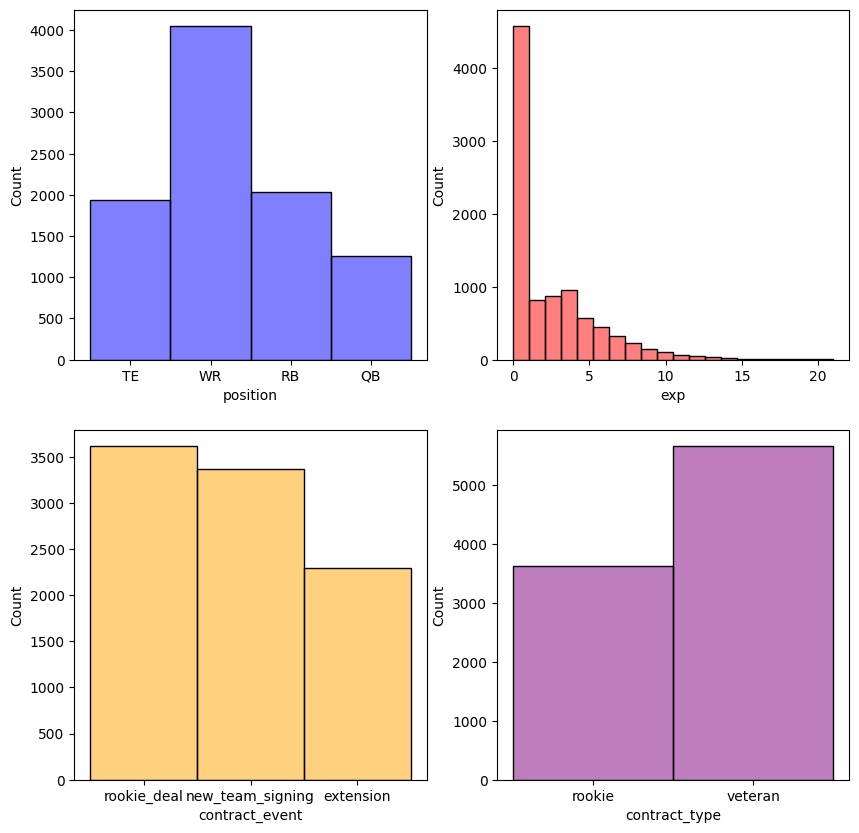

In [228]:
#====================================
# Contract Data Counts
#====================================
fig , ax = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
sns.histplot(contract_final['position'], bins = 20, alpha= 0.5, color = 'blue', ax = ax[0,0])
sns.histplot(contract_final['exp'], bins = 20, alpha= 0.5, color = 'red', ax=ax[0,1])
sns.histplot(contract_final['contract_event'], bins = 20, alpha= 0.5, color = 'orange', ax=ax[1,0])
sns.histplot(contract_final['contract_type'], bins = 20, alpha= 0.5, color = 'purple', ax=ax[1,1])

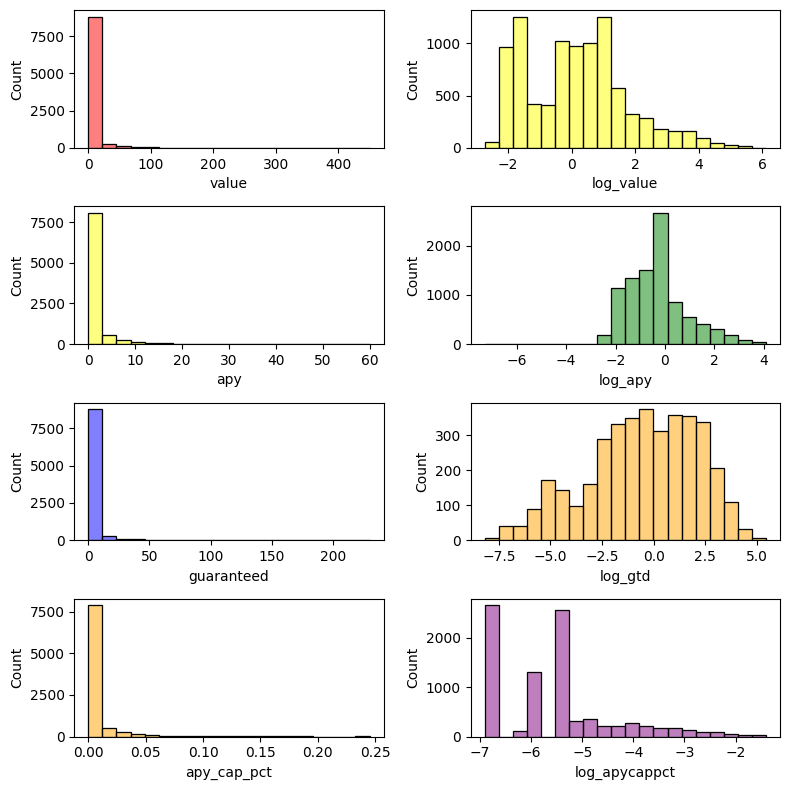

In [229]:
#====================================
# Contract Data Counts
#====================================
fig, ax = plt.subplots(4 , 2, figsize=(8,8))
sns.histplot(contract_final['value'], bins = 20, alpha= 0.5, color = 'red', ax=ax[0,0])
sns.histplot(contract_final['log_value'], bins = 20, alpha= 0.5, color = 'yellow', ax=ax[0,1])
sns.histplot(contract_final['apy'], bins = 20, alpha= 0.5, color = 'yellow', ax=ax[1,0])
sns.histplot(contract_final['log_apy'], bins = 20, alpha= 0.5, color = 'green', ax=ax[1,1])
sns.histplot(contract_final['guaranteed'], bins = 20, alpha= 0.5, color = 'blue', ax=ax[2,0])
sns.histplot(contract_final['log_gtd'], bins = 20, alpha= 0.5, color = 'orange', ax=ax[2,1])
sns.histplot(contract_final['apy_cap_pct'], bins = 20, alpha= 0.5, color = 'orange', ax=ax[3,0])
sns.histplot(contract_final['log_apycappct'], bins = 20, alpha= 0.5, color = 'purple', ax=ax[3,1])
plt.tight_layout()
plt.show()

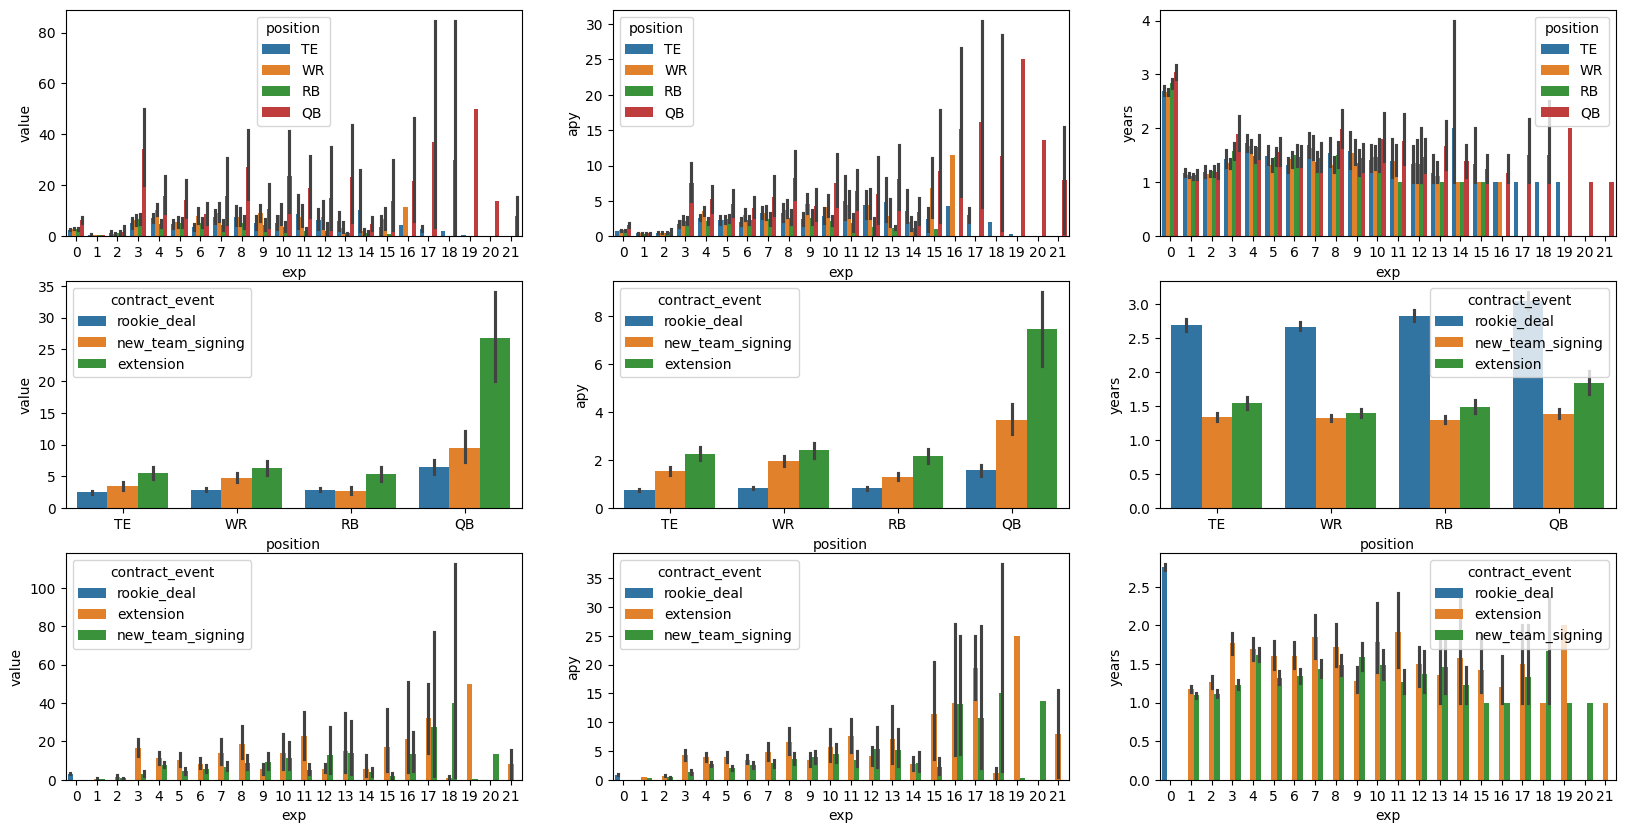

In [230]:
# Contract Features Box and Bar plots with
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(20, 10))
cols = ['value','apy','years']
for i, col in enumerate(cols):
    sns.barplot(x='exp', y=col, hue = 'position', data=contract_final, ax=ax[0,i])
    sns.barplot(x='position', y=col, hue = 'contract_event', data=contract_final, ax=ax[1,i])
    sns.barplot(x='exp', y=col, hue = 'contract_event', data=contract_final, ax=ax[2,i])

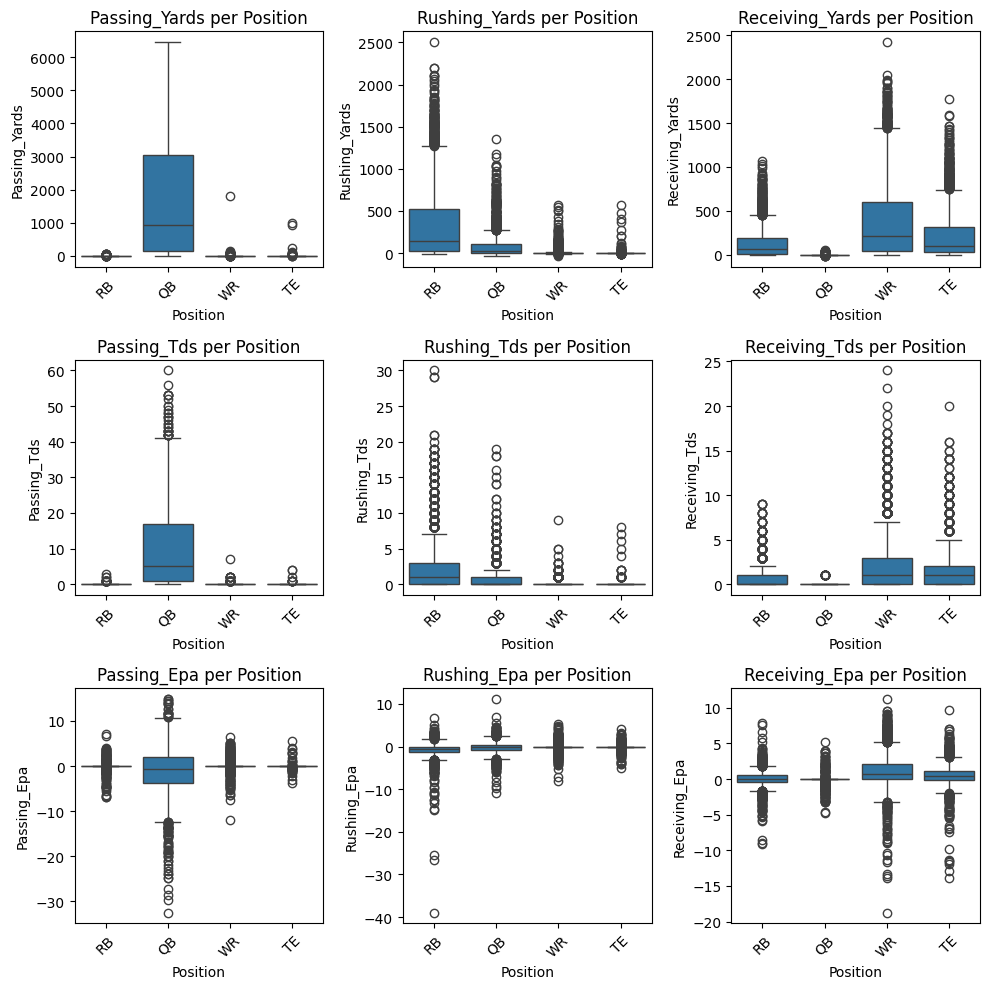

In [260]:
#====================================
# Player Stats Data - Whole Season
#====================================
stats = ('_yds','_tds','_epa')
s_type = ('p_','ru_','rec')
prurec_ydstds = []
for stat in stats:
  matched = [col for col in tot_plyr_sts.columns
             if stat in col
             and col.startswith(s_type)]
  prurec_ydstds.extend(matched)

fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))
ax = ax.flatten() # Reassign flattened array to ax
for i, col in enumerate(prurec_ydstds):
  label = col.replace('_tot', '')
  sns.boxplot(x='position', y=col, data=tot_plyr_sts, ax=ax[i])
  ax[i].set_title(f'{reverse_stat_dictionary[label].title()} per Position')
  ax[i].set_xlabel('Position')
  ax[i].set_ylabel(reverse_stat_dictionary[label].title())
  ax[i].tick_params(rotation=45, axis = 'x')
plt.tight_layout()
plt.show()

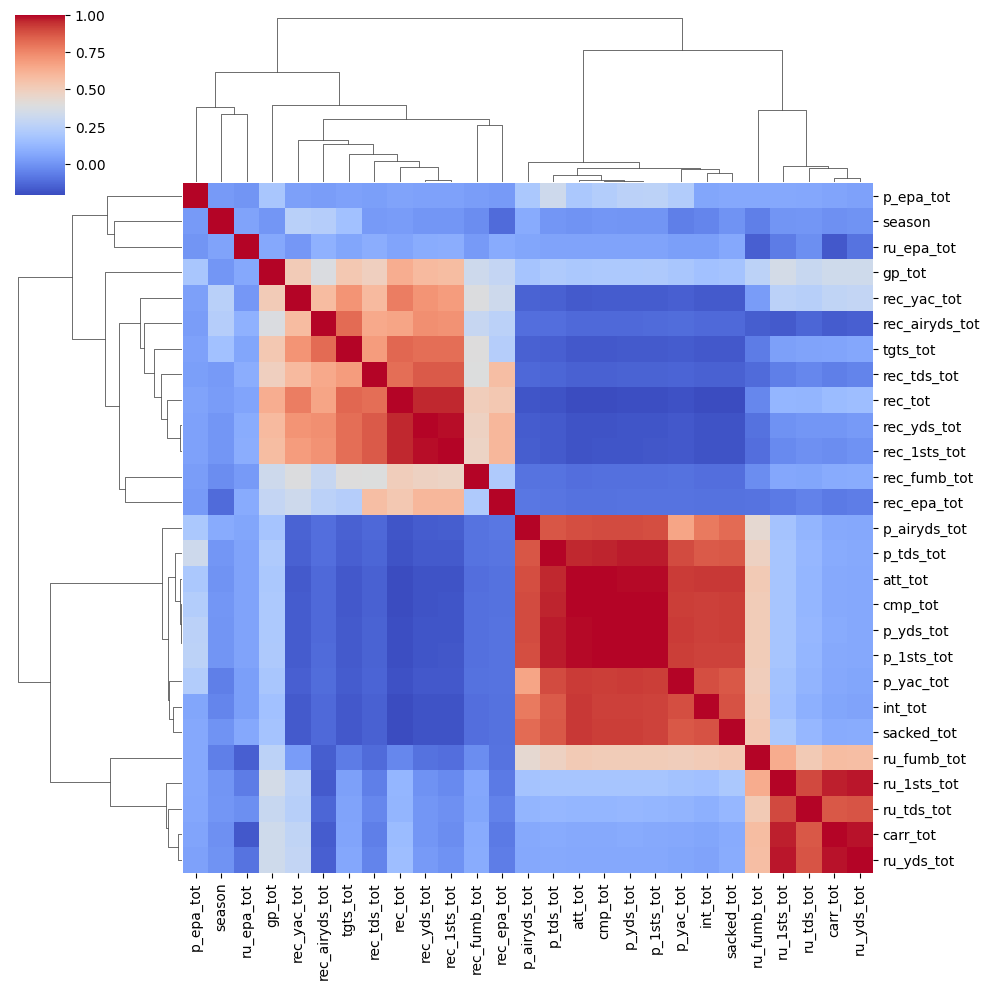

In [232]:
# Creation of a Heatmap for team stats.
plyr_corr = tot_plyr_sts.corr(numeric_only = True)
sns.clustermap(plyr_corr, cmap='coolwarm')

After looking at our cleaned Datasets, we see that player specific stats are significant overall. It would be difficult to establish a model that would be universal overall for the 4 key skill positions we identified.  
We will look to build a base model for all players combined, as well as differentiating them per position and key stat groupings.  
Ultimately, we will look at understanding key features for each and which may or may not overlap between models.  

It would also prove beneficial to see how each metrics group relates to our ultimate target of APY contract value.

In [233]:
# Merging Total Player Sats and Team Records to See win/loss impact on APY/Value
# of Contract
tot_plyr_sts_rcds = pd.merge(tot_plyr_sts,tot_tm_rcds, on=['team','season'], how='left', suffixes=('_plyr','_tm'))
tot_plyr_sts_rcds

,season,team,player,position,gp_tot_plyr,cmp_tot,att_tot,p_yds_tot,p_tds_tot,int_tot,sacked_tot,p_airyds_tot,p_yac_tot,p_1sts_tot,carr_tot,ru_yds_tot,ru_tds_tot,ru_fumb_tot,ru_1sts_tot,rec_tot,tgts_tot,rec_yds_tot,rec_tds_tot,rec_fumb_tot,rec_airyds_tot,rec_yac_tot,rec_1sts_tot,p_epa_tot,ru_epa_tot,rec_epa_tot,w_tot,l_tot,gp_tot_tm
0,2000,IND,Abdul-Karim al-Jabbar,RB,1,0,0,0,0,0,0,0,0,0,1,-2,0,0,0,0,0,0,0,0,0,0,0,0.000000,-0.549944,0.000000,10.0,7.0,17.0
1,2000,TB,Rabih Abdullah,RB,10,0,0,0,0,0,0,0,0,0,16,70,0,0,5,2,2,14,0,0,0,0,1,0.000000,-0.942835,0.148687,10.0,7.0,17.0
2,2001,TB,Rabih Abdullah,RB,14,0,0,0,0,0,0,0,0,0,11,40,0,0,1,2,2,26,0,0,0,0,2,0.000000,-0.418693,2.192011,9.0,8.0,17.0
3,2002,CHI,Rabih Abdullah,RB,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,4.0,12.0,16.0
4,2003,CHI,Rabih Abdullah,RB,15,0,0,0,0,0,0,0,0,0,18,37,0,0,4,8,0,55,0,0,0,0,3,0.000000,-0.397004,-0.091629,7.0,9.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14838,2025,LA,Terrance Ferguson,TE,13,0,0,0,0,0,0,0,0,0,1,0,0,0,0,12,31,250,3,0,554,43,10,0.000000,-1.549391,0.315279,14.0,6.0,20.0
14839,2025,SEA,Elijah Arroyo,TE,13,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15,26,179,1,1,220,78,7,0.000000,0.000000,-1.249147,17.0,3.0,20.0
14840,2025,NO,Tyler Shough,QB,11,221,327,2384,10,6,31,2708,1051,107,45,186,3,1,12,0,0,0,0,0,0,0,0,0.187267,0.102318,0.000000,6.0,11.0,17.0
14841,2025,CLE,Isaiah Bond,WR,15,0,0,0,0,0,0,0,0,0,5,29,0,0,1,18,44,338,0,0,751,79,11,0.000000,0.175834,-0.057465,5.0,12.0,17.0


In [234]:
contract_final.columns

Index(['player', 'position', 'team', 'year_signed', 'years', 'value', 'apy',
       'guaranteed', 'apy_cap_pct', 'draft_year', 'draft_team', 'log_value',
       'log_apy', 'log_gtd', 'log_apycappct', 'contract_type', 'exp',
       'prev_team', 'contract_event', 'contract_id'],
      dtype='object')

In [235]:
tot_plyr_sts.columns

Index(['season', 'team', 'player', 'position', 'gp_tot', 'cmp_tot', 'att_tot',
       'p_yds_tot', 'p_tds_tot', 'int_tot', 'sacked_tot', 'p_airyds_tot',
       'p_yac_tot', 'p_1sts_tot', 'carr_tot', 'ru_yds_tot', 'ru_tds_tot',
       'ru_fumb_tot', 'ru_1sts_tot', 'rec_tot', 'tgts_tot', 'rec_yds_tot',
       'rec_tds_tot', 'rec_fumb_tot', 'rec_airyds_tot', 'rec_yac_tot',
       'rec_1sts_tot', 'p_epa_tot', 'ru_epa_tot', 'rec_epa_tot'],
      dtype='object')

In [236]:
contract_subset = contract_final[['player','position','team','exp','year_signed','value','apy','log_value','log_apy','contract_event','draft_year','contract_id']].copy()

# Inner merge contract subset with player stats and records
# This will create a new Dataframe where each contract event will have all the stats available
# for each player.
merged = tot_plyr_sts_rcds.merge(contract_subset, on = ['player','position'], how = 'inner')

# Filter the data for player stats prior to the year contract was signed,
# removing stats during or after contracts.
merged = merged[merged['year_signed'] > merged['season']]

# Filter out older players who have names that match recent players
merged = merged[merged['season'] >= merged['draft_year']]


# Define the desired order of columns explicitly
start_cols = ['player', 'position', 'season', 'team_x']
contract_info_cols = ['team_y','year_signed','exp', 'value','apy','log_value','log_apy', 'contract_event', 'draft_year', 'contract_id']

# Get all other columns, excluding those already in start_cols or contract_info_cols
remaining_cols = [col for col in merged.columns if col not in (set(start_cols) | set(contract_info_cols))]

# Assemble the new column order
col_swap = start_cols + contract_info_cols + remaining_cols

m = merged[col_swap]

In [237]:
# Seperate Columns between id/ stats
id_cols = ['player','position','season','team']
stat_cols = [
    col for col in tot_plyr_sts_rcds.columns if col not in set(id_cols)
]

# Establish all Aggregations to be used for baseline models.
# We are using differnt forms for all stats leading up to a contract year.
all_aggregations = {
    col: ['sum','mean','max']
    for col in stat_cols
}
# Also use specific addition and average metrics leading up to contract event.
sum_agg = {col: 'sum' for col in stat_cols}
mean_agg = {col: 'mean' for col in stat_cols}

# Create Dataframes given all of the aggregations.
sum_agg = m.groupby('contract_id').agg(sum_agg)
mean_agg = m.groupby('contract_id').agg(mean_agg)
all_agg = (m.groupby('contract_id').agg(all_aggregations))

# Merge the data frames with the original contracts data frame on contract_id.
# Giving us all aggregations of stats prior to each contract event.
sum_agg.reset_index()
contract_sts_sum = contract_final.merge(sum_agg, on='contract_id', how='inner')

mean_agg = mean_agg.reset_index()
contract_sts_mean = contract_final.merge(mean_agg, on='contract_id', how='inner')

all_agg.columns = [f'{col[0]}_{col[1]}' for col in all_agg.columns]
all_agg = all_agg.reset_index()
contract_sts_agg = pd.merge(contract_final, all_agg, on='contract_id', how='inner')

# Removing unnecessary ID columns. Potential targets identified.
id_cols_drp =['player','team','year_signed','draft_year','years','value', 'guaranteed', 'apy_cap_pct','draft_team','contract_type','prev_team','contract_id','log_value','log_apy', 'log_gtd','log_apycappct']

cntrct_sum = contract_sts_sum.drop(columns=id_cols_drp)
cntrct_mean = contract_sts_mean.drop(columns=id_cols_drp)
cntrct_agg = contract_sts_agg.drop(columns=id_cols_drp)

In [238]:
# Create dataframes that are specific to each position.
# QB's
qb_agg = cntrct_agg[cntrct_agg['position'] == 'QB'].drop(columns=['position'])
qb_sum = cntrct_sum[cntrct_sum['position'] == 'QB'].drop(columns=['position'])
qb_mean = cntrct_mean[cntrct_mean['position'] == 'QB'].drop(columns=['position'])
# RB's
rb_agg = cntrct_agg[cntrct_agg['position'] == 'RB'].drop(columns=['position'])
rb_sum = cntrct_sum[cntrct_sum['position'] == 'RB'].drop(columns=['position'])
rb_mean = cntrct_mean[cntrct_mean['position'] == 'RB'].drop(columns=['position'])
# WR's
wr_agg = cntrct_agg[cntrct_agg['position'] == 'WR'].drop(columns=['position'])
wr_sum = cntrct_sum[cntrct_sum['position'] == 'WR'].drop(columns=['position'])
wr_mean = cntrct_mean[cntrct_mean['position'] == 'WR'].drop(columns=['position'])
# TE's
te_agg = cntrct_agg[cntrct_agg['position'] == 'TE'].drop(columns=['position'])
te_sum = cntrct_sum[cntrct_sum['position'] == 'TE'].drop(columns=['position'])
te_mean = cntrct_mean[cntrct_mean['position'] == 'TE'].drop(columns=['position'])

In [239]:
stat_groups = {
    'passing': [
        'att',
        'cmp',
        'p_yds',
        'p_tds',
        'int',
        'sacked',
        'p_airyds',
        'p_yac',
        'p_1sts',
        'p_epa'
    ],
    'rushing': [
        'carr',
        'ru_yds',
        'ru_tds',
        'ru_fumb',
        'ru_1sts',
        'ru_epa'
    ],
    'receiving': [
        'rec',
        'tgts',
        'rec_yds',
        'rec_tds',
        'rec_fumb',
        'rec_airyds',
        'rec_yac',
        'rec_1sts',
        'rec_epa'
    ],
    'epas' : [
        'p_epa',
        'ru_epa',
        'rec_epa'
    ],
    'tds' : [
        'p_tds',
        'ru_tds',
        'rec_tds'
    ],
    'yds' : [
        'p_yds',
        'ru_yds',
        'rec_yds'
    ]
}

In [240]:
## Function for plotting regplots for data given features.
import math
def regplot_array(data,features, color= None):
 n_cols = 4
 n_rows = math.ceil(len(features) / n_cols)
 fig, ax = plt.subplots(
      n_rows,
      n_cols,
      figsize=(5 * n_cols, 4 * n_rows)
  )
 ax = ax.flatten()
 for i, col in enumerate(features):
    col_name = f'{col}_tot'
    sns.regplot(data=data, x=col_name, y='apy', ax=ax[i], color = color)

    ax[i].set_title(f'{reverse_stat_dictionary[col].title()} v. APY')
    ax[i].set_xlabel(reverse_stat_dictionary[col].title())
    ax[i].set_ylabel('APY')
    ax[i].tick_params(rotation=45, axis = 'x')
  # Remove unused plots
 for j in range(i + 1, len(ax)):
      fig.delaxes(ax[j])
 plt.tight_layout()
 plt.show()

After creating contract event datasets with aggregated stats, we will do a quick look to see how each of the sum aggregations relate to the APY.

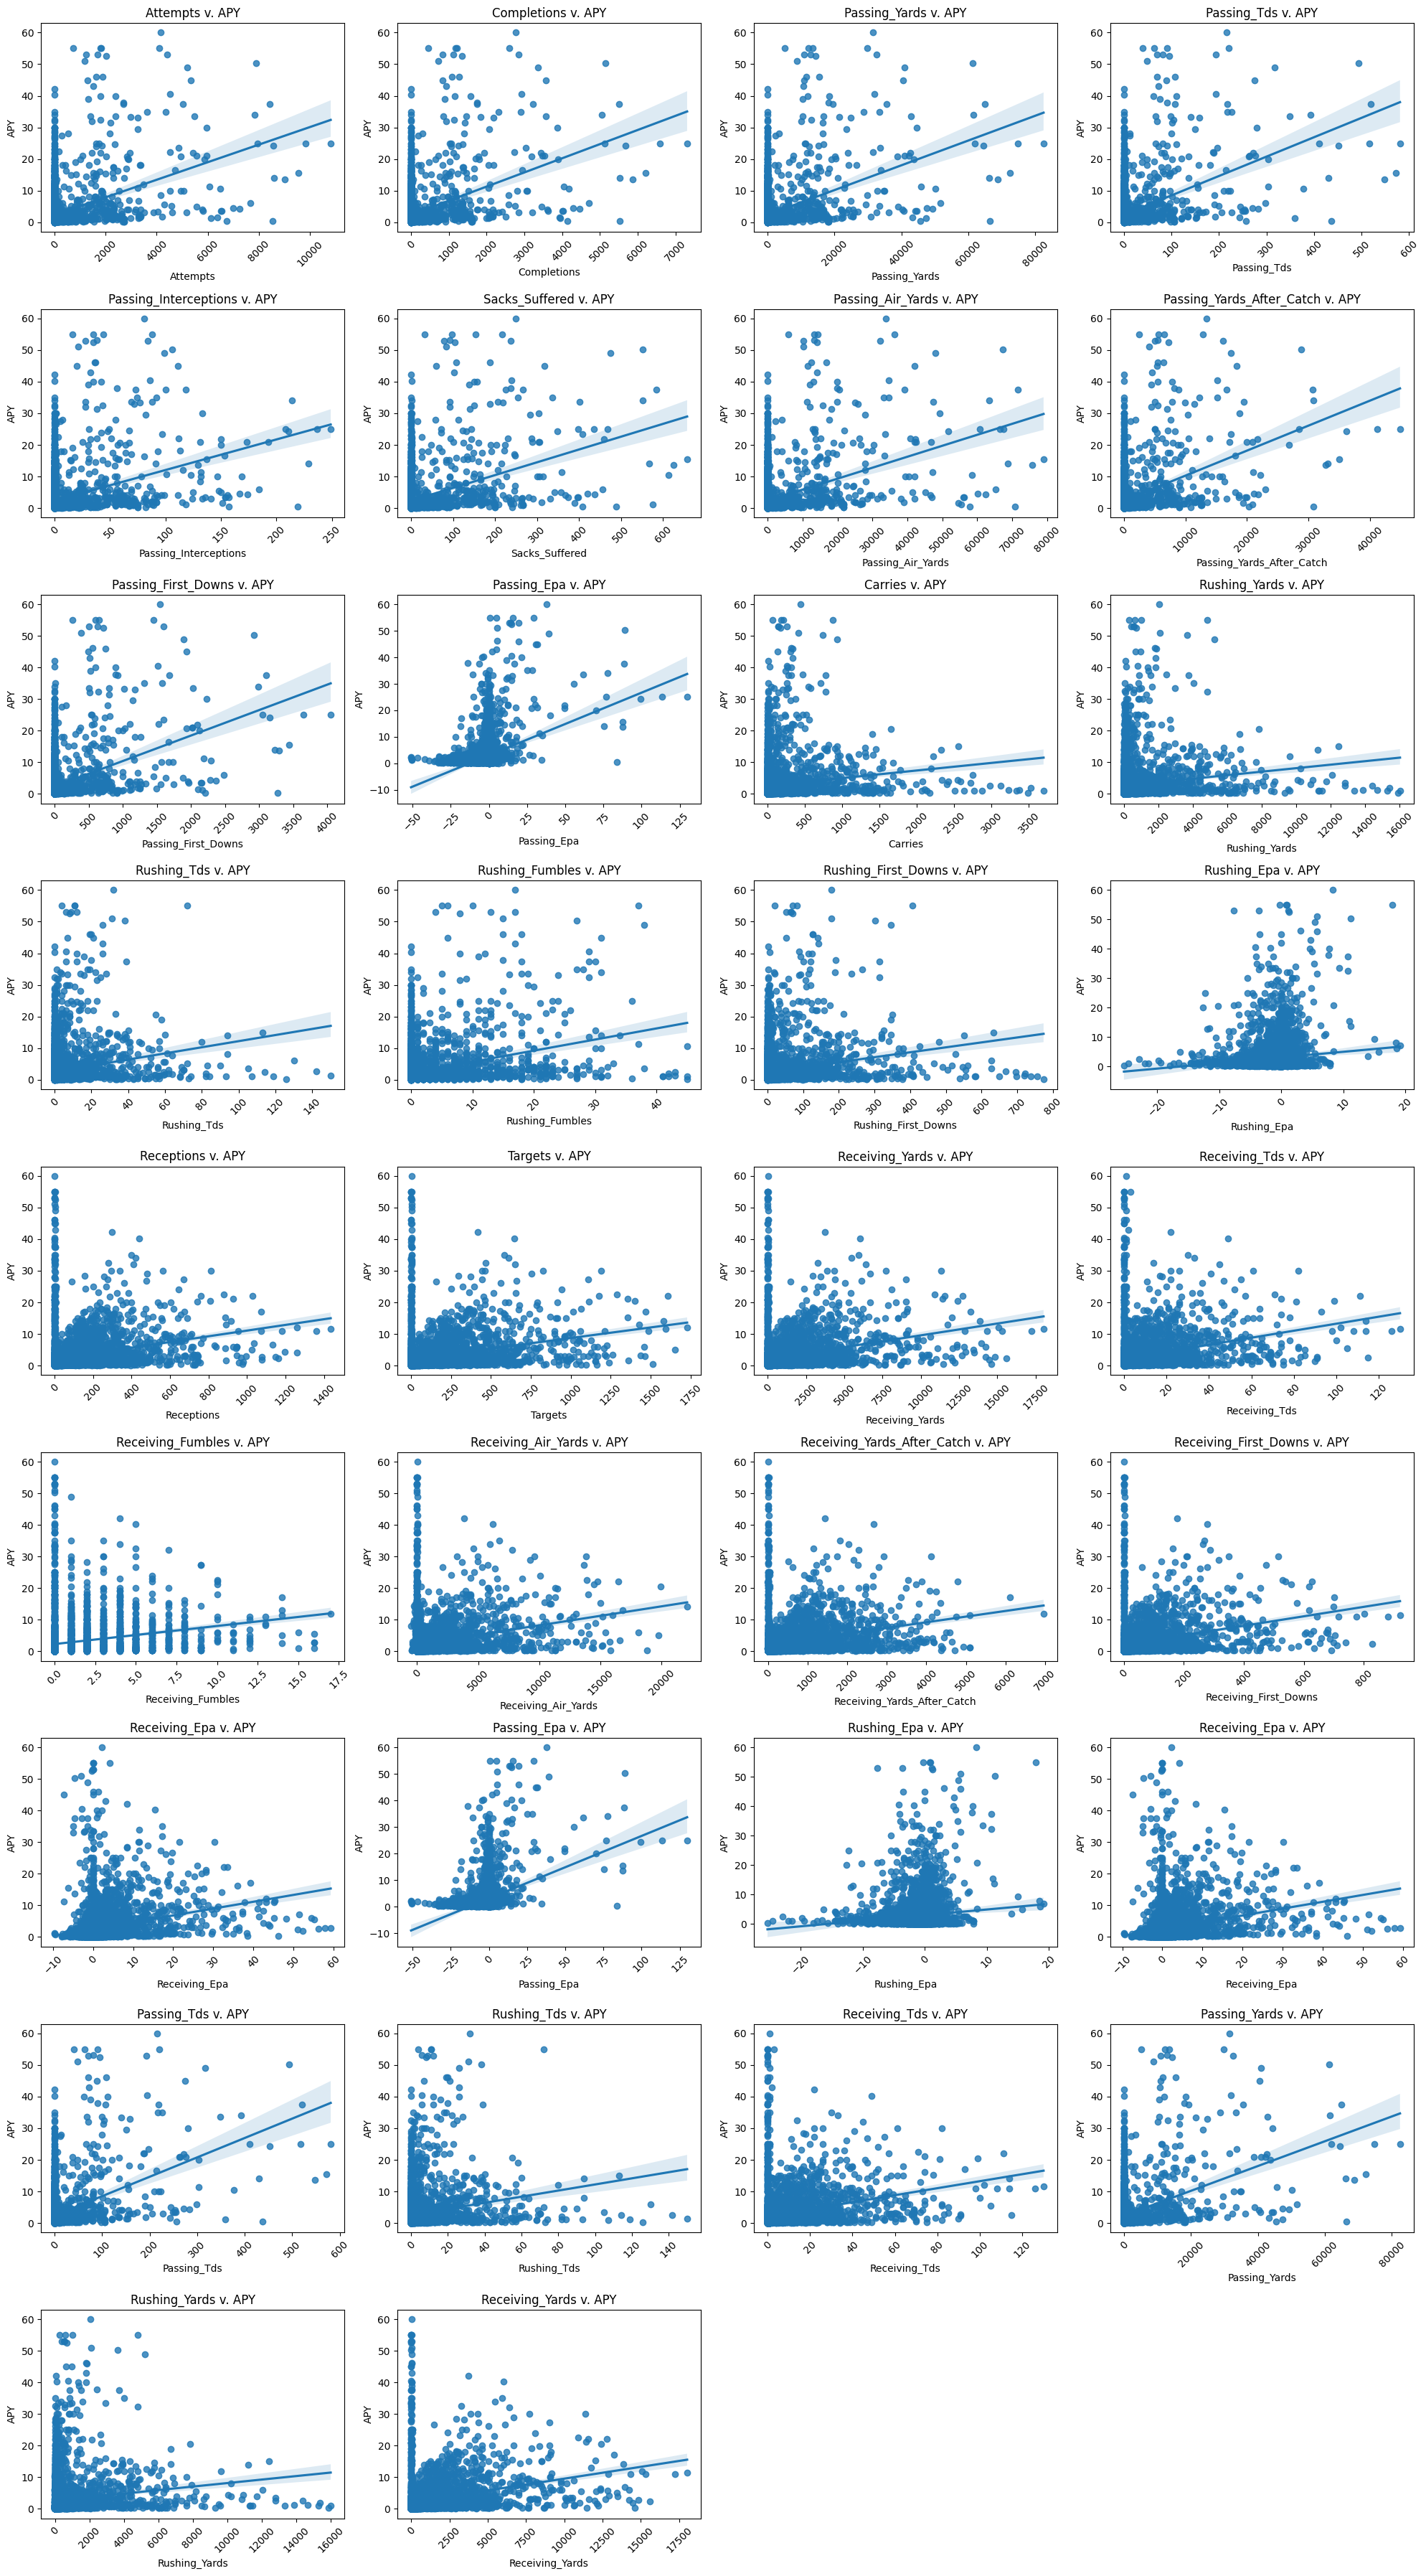

In [241]:
# Group all features and create regplots for them with sum aggregate of entire data set.
feature = stat_groups['passing'] + stat_groups['rushing'] + stat_groups['receiving'] + stat_groups['epas'] + stat_groups['tds'] + stat_groups['yds']
contract_means = regplot_array(cntrct_sum,feature)


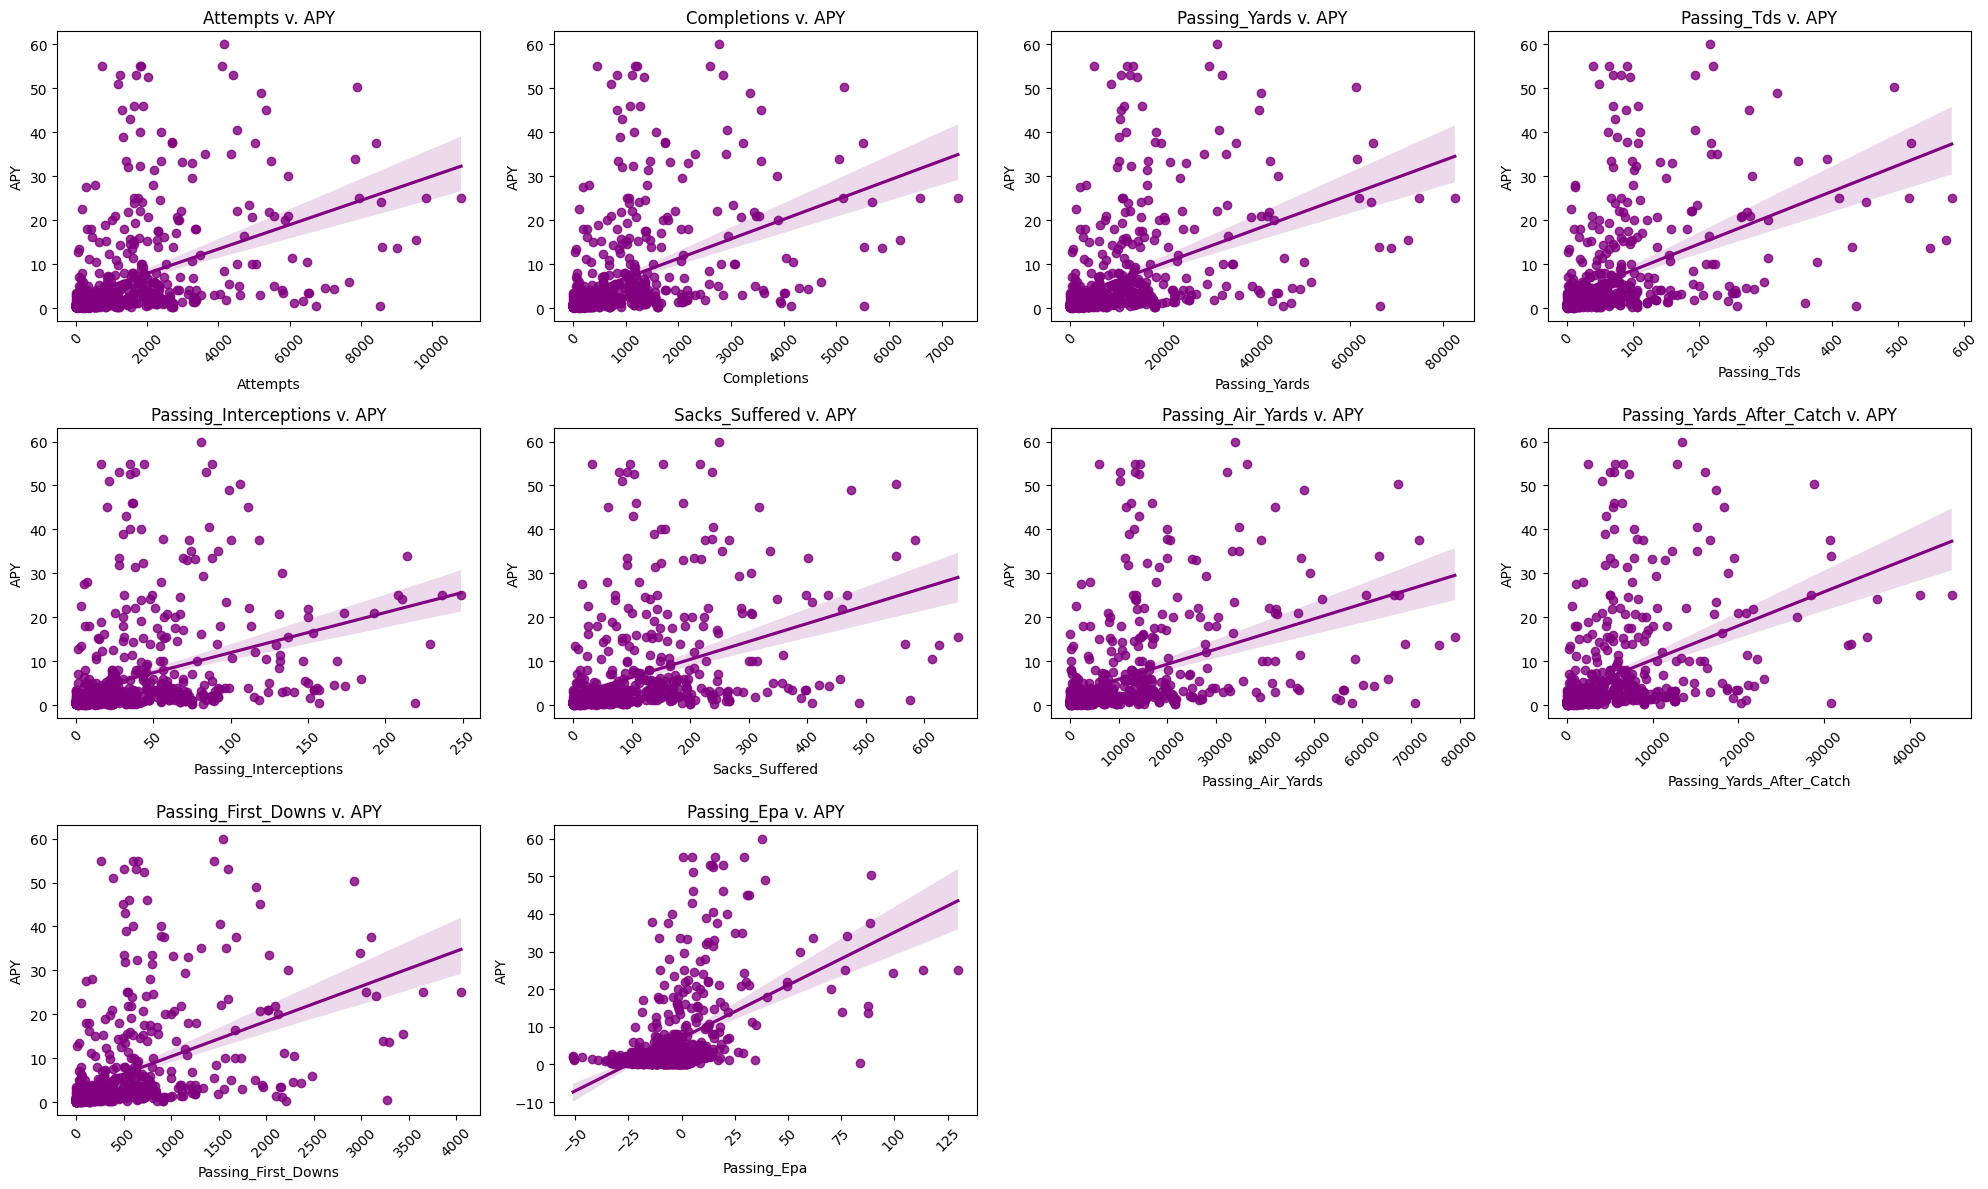

In [242]:
# Plotting QBs with all passing metrics.
qb_sums = regplot_array(qb_sum,stat_groups['passing'] , 'purple')

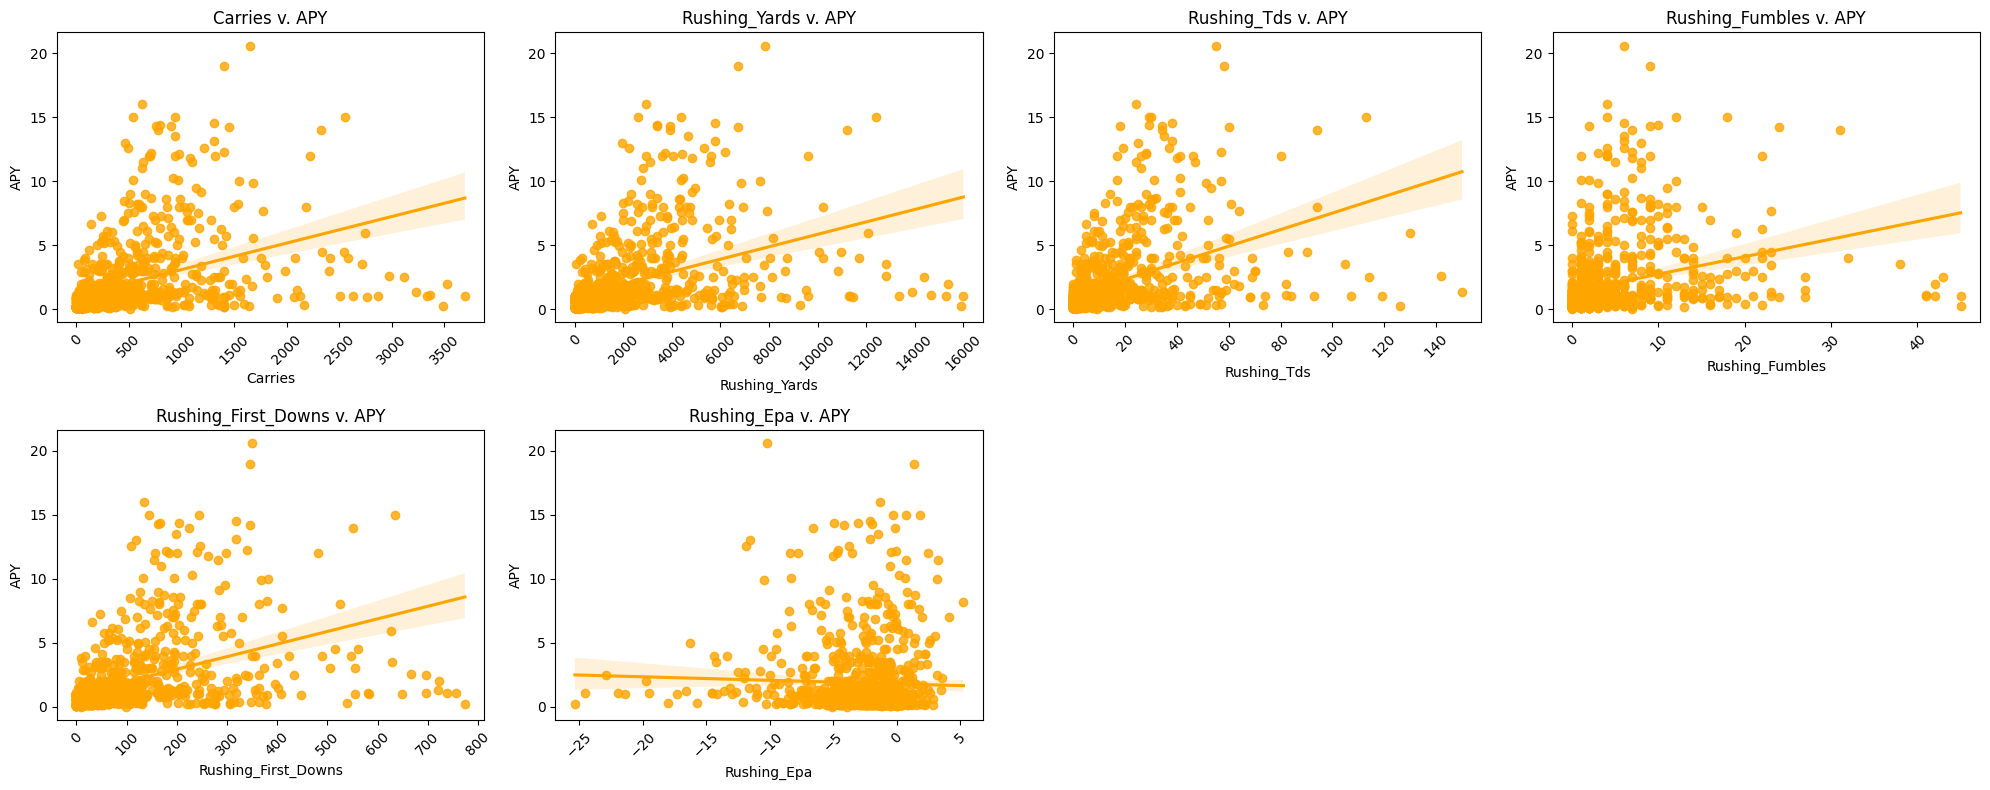

In [243]:
# Running back sums with all rushing metrics.
rb_sums = regplot_array(rb_sum,stat_groups['rushing'] , 'orange')

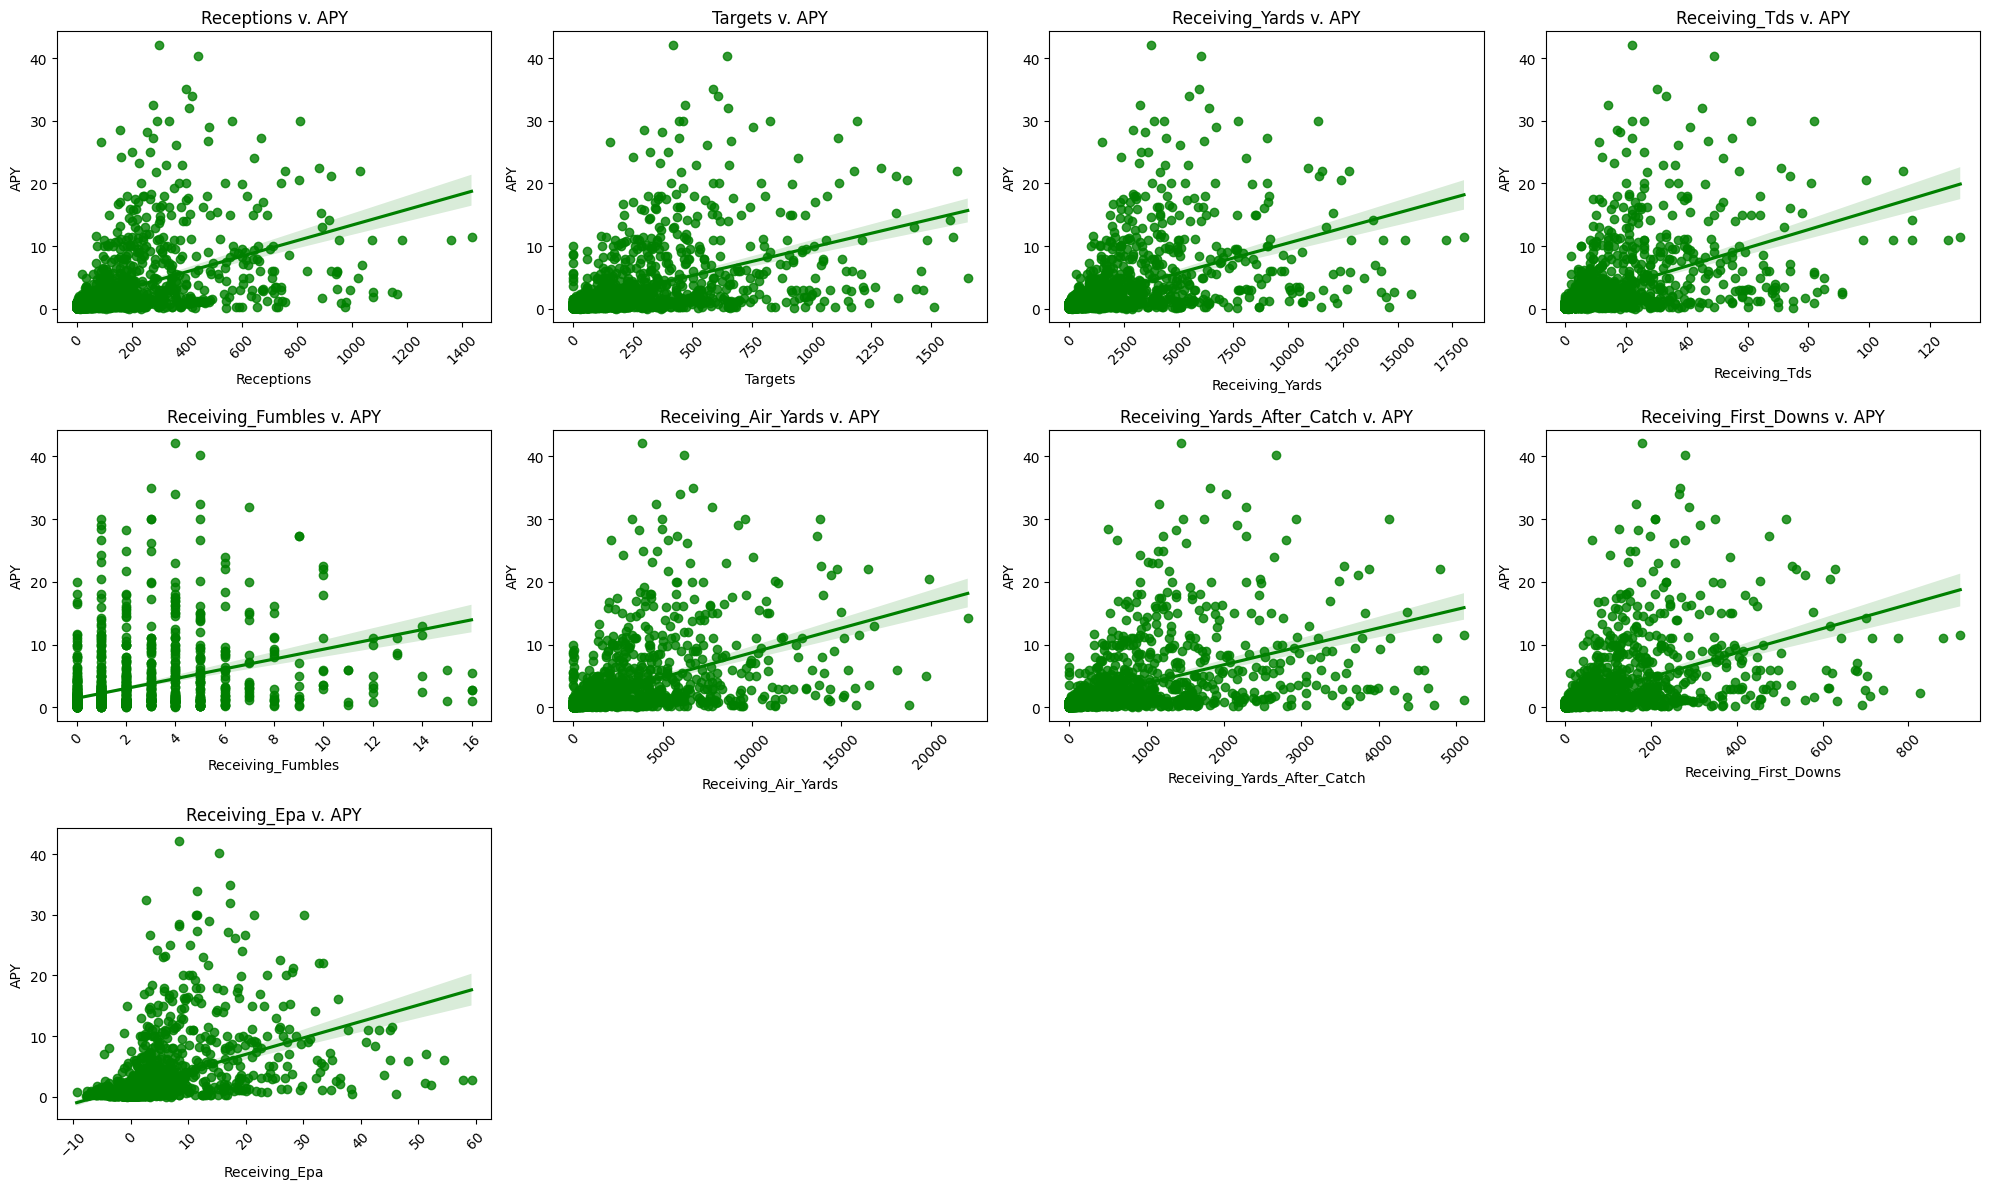

In [244]:
# WR sums for all receiving metrics.
wr_sums = regplot_array(wr_sum,stat_groups['receiving'] , 'green')

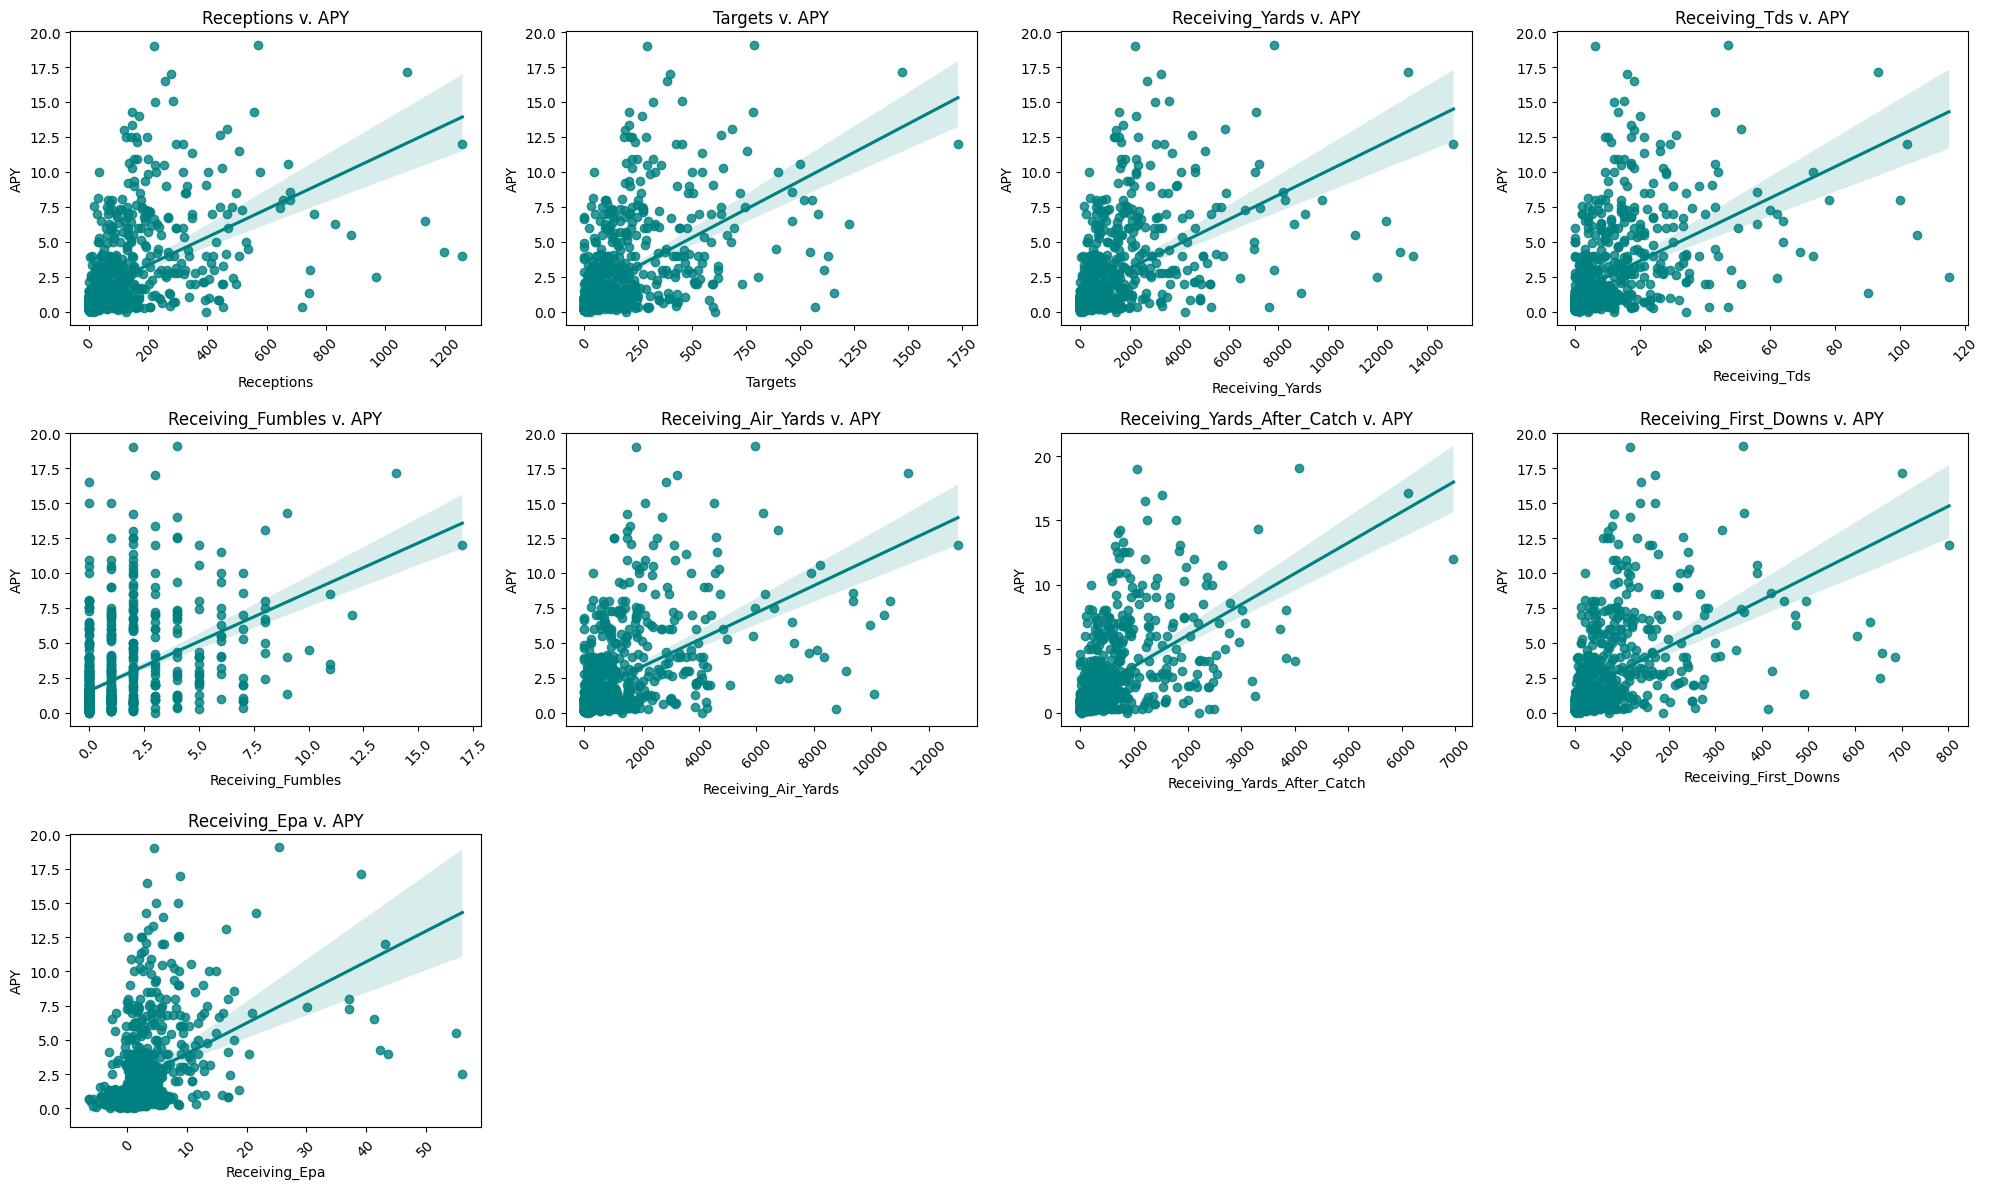

In [245]:
# TE sums for all receiving metrics .
te_sums = regplot_array(te_sum,stat_groups['receiving'] , 'teal')

We see that seperation by position allows for better learnings to be made, as there is less data points where the total is 0 as it does not apply to the position group.  
We will now create some baseline Models for each of the groups above.

In [246]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, root_mean_squared_error

In [247]:
# Creating a function for running model experiments.
def run_model_experiments(data,target,features,model_dict,test_size=0.2,random_state=42):
  # Seperate data between features and target
  X = data[features]
  y = data[target]

  # Establish a test / train split.
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
  # Track results, trained models and store predictions for analysis.
  results = []
  trained_models = {}
  prediction_store = {}
  # Loop through dictionary of models given.
  for model_name, pipeline in model_dict.items():
    pipeline.fit(X_train, y_train)
    train_preds = pipeline.predict(X_train)
    test_preds = pipeline.predict(X_test)

    #RMSE
    train_rmse = root_mean_squared_error(y_train, train_preds)
    test_rmse = root_mean_squared_error(y_test, test_preds)

    #MAE
    train_mae = mean_absolute_error(y_train, train_preds)
    test_mae = mean_absolute_error(y_test, test_preds)

    #R2
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    results.append({
        'model': model_name,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_r2': train_r2,
        'test_r2': test_r2,})

    trained_models[model_name] = pipeline
    prediction_store[model_name] = pd.DataFrame({
        'actual' : y_test,
        'predicted' : test_preds
    })
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='test_rmse', ascending=True)
  return {
      'results' : results_df,
      'models': trained_models,
      'predictions' : prediction_store
  }


In [248]:
# Seperate Features for Modeling of All data
cat_fts = ['position','contract_event','exp']
num_fts = [col for col in cntrct_sum.columns if col not in set(cat_fts + ['apy'])]

# Column Transformer for categorical and numerical data
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_fts),
        ('num', StandardScaler(), num_fts)
        ])

# PipeLines for all data.
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])
lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso())
])


# Model Dictionary.
models = {
    'linear_reg' : lr_pipeline,
    'ridge' : ridge_pipeline,
    'lasso' : lasso_pipeline,
    }

In [249]:
# Feature seperation for position specific data
cat_ft = ['contract_event','exp']
num_ft = [col for col in qb_sum.columns if col not in set(cat_ft + ['apy'])]

# Column Transformer for categorical and numerical data
pos_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_ft),
        ('num', StandardScaler(), num_ft)
        ])

# Pipes for Position specific Data
poslr_pipeline = Pipeline([
    ('preprocessor', pos_preprocessor),
    ('regressor', LinearRegression())
])
posridge_pipeline = Pipeline([
    ('preprocessor', pos_preprocessor),
    ('regressor', Ridge())
])
poslasso_pipeline = Pipeline([
    ('preprocessor', pos_preprocessor),
    ('regressor', Lasso())
])

# Position Models Dictionary
pos_models = {
    'linear_reg' : poslr_pipeline,
    'ridge' : posridge_pipeline,
    'lasso' : poslasso_pipeline,
    }

In [250]:
tot_results = run_model_experiments(cntrct_sum, 'apy', cat_fts + num_fts, models)

In [251]:
qb_results = run_model_experiments(qb_sum, 'apy', cat_ft + num_ft, pos_models)

In [252]:
rb_results = run_model_experiments(rb_sum, 'apy', cat_ft + num_ft, pos_models)

In [253]:
wr_results = run_model_experiments(wr_sum, 'apy', cat_ft + num_ft, pos_models)

In [254]:
te_results = run_model_experiments(te_sum, 'apy', cat_ft + num_ft, pos_models)

In [255]:
tot_results['results']

,model,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
0,linear_reg,4.086269,4.310687,2.284924,2.425350,0.477565,0.509248
1,ridge,4.135234,4.355233,2.296155,2.440890,0.464970,0.499053
2,lasso,5.114447,5.403534,2.720782,2.855783,0.181581,0.228875


In [256]:
qb_results['results']

,model,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
2,lasso,8.835899,8.797682,5.382329,5.126927,0.329036,0.306924
1,ridge,7.184992,9.310245,4.739071,5.493939,0.556340,0.223812
0,linear_reg,6.874768,10.067497,4.489752,5.962607,0.593824,0.092415


In [257]:
rb_results['results']

,model,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
1,ridge,1.944804,2.002947,1.301858,1.268706,0.537676,0.455865
0,linear_reg,1.904260,2.052935,1.270641,1.283253,0.556752,0.428366
2,lasso,2.737804,2.568100,1.734465,1.693417,0.083781,0.105478


In [258]:
wr_results['results']

,model,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
0,linear_reg,3.279738,3.869263,1.941332,2.198372,0.515971,0.487877
1,ridge,3.322052,3.874908,1.939200,2.178861,0.503401,0.486381
2,lasso,4.174523,4.844259,2.262365,2.577887,0.215837,0.197264


In [259]:
te_results['results']

,model,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
1,ridge,2.110169,2.326032,1.417675,1.531453,0.540248,0.391105
0,linear_reg,2.066584,2.586879,1.394776,1.671104,0.559044,0.246882
2,lasso,2.743631,2.655509,1.922870,1.867237,0.222786,0.206391


From the baseline models created above with a basic aggregation of stats leading up to the contract event, we see that the positional models performed better than the grouped model with all positions for all but 1 position, the Quarterback position. This is understandable as the QB position is one that is critiqued on much more than overall stat accumulation. Efficiency metrics are important to consider for this group especially to improve the model performance.